# 01. Сборка датасета признаков

Этот ноутбук оставляет основную исследовательскую логику подготовки признаков прямо в ячейках: загрузка данных, sanity checks, базовая метеофизика, сглаживания, empirical power curve, геометрия ВЭС, wake-risk и full-physics признаки. В конце сохраняется явный контракт для обучения.

In [1]:
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

from scipy.interpolate import PchipInterpolator
from scipy.spatial.distance import pdist, squareform

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.isotonic import IsotonicRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

In [2]:
# Управление отображением и диагностическими артефактами текущего запуска.
# Финальный submission сохраняется в каталоге текущего запуска.
PLOT_RESEARCH_OUTPUTS = False
PLOT_TWO_STAGE_DIAGNOSTICS = False
SAVE_DIAGNOSTIC_ARTIFACTS = False
SAVE_DIRECT_DEBUG_SUBMISSIONS = False

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [3]:
RANDOM_STATE = 42

In [4]:
# -------------------------
# Физика станции
# -------------------------
INSTALLED_CAPACITY_MW = 90.09
TURBINES_TOTAL = 26

CUT_IN_SPEED = 3.0
RATED_SPEED = 12.0
CUT_OUT_SPEED = 25.0

AIR_DENSITY_REF = 1.225
EPS = 1e-6


In [5]:
# -------------------------
# Пути проекта
# -------------------------
DATA_DIR = Path("data")
OUT_DIR = Path("outputs")
DATA_OUT_DIR = OUT_DIR / "data"
FIGURE_DIR = OUT_DIR / "figures"

for directory in [OUT_DIR, DATA_OUT_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

TRAIN_CANDIDATES = [
    DATA_DIR / "train_merged.csv",
    DATA_DIR / "train.csv",
]

VALID_CANDIDATES = [
    DATA_DIR / "valid_merged.csv",
    DATA_DIR / "valid.csv",
]

TRAIN_PATH = next((p for p in TRAIN_CANDIDATES if p.exists()), TRAIN_CANDIDATES[0])
VALID_PATH = next((p for p in VALID_CANDIDATES if p.exists()), VALID_CANDIDATES[0])

TURBINE_COORDS_CANDIDATES = [
    Path("map") / "data" / "wind_farm_coords.csv",
    Path("map") / "map_data" / "wind_farm_cords.csv",
    Path("map") / "wind_data" / "wind_farm_cords.csv",
]
TURBINE_COORDS_PATH = next((p for p in TURBINE_COORDS_CANDIDATES if p.exists()), TURBINE_COORDS_CANDIDATES[0])

# Основной файл для отправки.
SUB_PATH = OUT_DIR / "submission_final.csv"

# Диагностические submission-файлы direct ensemble.
DIRECT_SUB_PATH = DATA_OUT_DIR / "direct_full_clipped.csv"
DIRECT_RAW_PATH = DATA_OUT_DIR / "direct_full_raw.csv"

LOG_DIR = DATA_OUT_DIR
RESEARCH_PLOT_DIR = FIGURE_DIR
TS_DIR = DATA_OUT_DIR / "two_stage"


In [6]:
# -------------------------
# Блоки текущего запуска
# -------------------------
FULL_PHYSICS_BLOCK_ENABLED = True
HIGH_WIND_CLIP_ENABLED = True
TWO_STAGE_ENABLED = True

RUN_FINAL_PIPELINE = True
RUN_LOCAL_CHECK = False
PLOT_FINAL_DISTRIBUTIONS = True
RUN_POWER_CURVE_DIAGNOSTIC = True
RUN_HIGH_WIND_CLIP_TUNING = False


In [7]:
# -------------------------
# Веса direct ensemble
# Можно аккуратно крутить веса, но сумма должна быть около 1.
# -------------------------
BLEND_WEIGHTS = {
    "cat_mae_direct": 0.361831,
    "hgb_q545": 0.235409,
    "xgb_residual": 0.177644,
    "hgb_q570": 0.116581,
    "lgb_residual": 0.064663,
    "hgb_q530": 0.043873,
}

# Размер direct ensemble. Если нужно быстрее — уменьши значения или поставь FAST_MODE в отдельных местах.
ENSEMBLE_PARAMS_FULL = {
    "cat_iter": 1200,
    "xgb_estimators": 900,
    "lgb_estimators": 900,
    "hgb_iter": 650,
}

ENSEMBLE_PARAMS_FAST = {
    "cat_iter": 500,
    "xgb_estimators": 450,
    "lgb_estimators": 450,
    "hgb_iter": 350,
}

HGB_QUANTILES = [0.545, 0.570, 0.530]
DIRECT_ENSEMBLE_FAST_MODE = False


In [8]:
# -------------------------
# Геометрия / wake
# -------------------------
N_LAYOUT_CLUSTERS = 4
LAYOUT_KMEANS_N_INIT = 30

WAKE_DIRECTION_STEP_DEG = 5
WAKE_LATERAL_THRESHOLD_M = 260
WAKE_MAX_DOWNWIND_M = 2500
WAKE_DECAY_DOWNWIND_M = 800

BEST_WAKE_FEATURE = "layout_wake_risk_scalar_120m"


In [9]:
# -------------------------
# Физическая декомпозиция скрытых потерь
# -------------------------
FULL_MIN_IDEAL_MW = 3.0
FULL_K_HIDDEN_LOW = -0.25
FULL_K_HIDDEN_HIGH = 0.95
FULL_CHANGEPOINT_WINDOW = 72
FULL_CHANGEPOINT_MIN_DISTANCE = 96
FULL_CHANGEPOINT_THRESHOLD_MAD = 3.5
FULL_MAX_OFF_GRID = TURBINES_TOTAL
FULL_AVAIL_LAMBDA = 0.0015
FULL_UPWIND_WEIGHT_BOOST = 0.35
FULL_OOF_SPLITS = 5
FULL_RANDOM_STATE = RANDOM_STATE


In [10]:
# -------------------------
# Empirical high-wind clip
# Параметры high-wind clip зафиксированы в конфигурации запуска.
# -------------------------
HIGH_WIND_SPEED_COL = "wind_speed_120m"
HIGH_WIND_START_WS = 11.5
HIGH_WIND_TRANSITION = 0.45
HIGH_WIND_CAP_QUANTILE = 0.70
HIGH_WIND_CAP_BIN_WIDTH = 0.50
HIGH_WIND_CAP_MIN_COUNT = 5
HIGH_WIND_CAP_ROLLING_WINDOW = 3
HIGH_WIND_CAP_MARGIN_MW = 1.5
HIGH_WIND_HARD_MAX_CAP = 77.0
HIGH_WIND_CLIP_STRENGTH = 0.85
HIGH_WIND_MIN_PRED = 0.0
HIGH_WIND_MAX_PRED = INSTALLED_CAPACITY_MW

# Cap-кривая как входной сигнал до обучения direct ensemble.
# Target не клипуется: модель получает только оценку high-wind потолка и gate.
HIGH_WIND_CAP_FEATURES_ENABLED = True

# Финальная конфигурация post-processing для submission_final.csv.
FINAL_BENCHMARK_VARIANT = "submission_alpha_0p100_aggressive_q65_cap76"
FINAL_CLIP_CONFIG = {
    "name": "aggressive_q65_cap76",
    "quantile": 0.65,
    "margin_mw": 1.0,
    "hard_max_cap": 76.0,
    "strength": 1.00,
}


In [11]:
# ============================================================
# TWO-STAGE CONFIG: normal behavior + deviation
# ============================================================

TWO_STAGE_ENABLED = True
TWO_STAGE_FAST_MODE = False

# Количество time-series split для OOF normal/deviation
TWO_STAGE_N_SPLITS = 5

# Финальная смесь:
# final = (1 - alpha) * direct_full + alpha * two_stage
# Коэффициент смешивания задаёт долю two-stage поправки в финальном прогнозе.
FINAL_TWO_STAGE_ALPHA = 0.10

# ============================================================
# Residual / deviation target clipping
# ============================================================
# Квантильная обрезка оставляет residual-модели редкие режимы станции.
TWO_STAGE_RESIDUAL_Q_LOW = 0.005
TWO_STAGE_RESIDUAL_Q_HIGH = 0.995
TWO_STAGE_RESIDUAL_CLIP_MULT = 1.25

# ============================================================
# Deviation prediction safety
# ============================================================
# Не зажимаем deviation: residual-ветка должна иметь право на крупную поправку.
# Значение 999 фактически отключает дополнительный absolute clip,
# остаётся только квантильная обрезка target/prediction.
TWO_STAGE_DEVIATION_SHRINK = 1.00
TWO_STAGE_DEVIATION_ABS_CLIP_MW = 999.0

# ============================================================
# Bad OOF head handling
# ============================================================
# Ранний OOF-участок участвует в обучении residual-модели.
TWO_STAGE_DROP_BAD_OOF_HEAD = False
TWO_STAGE_BAD_HEAD_FRAC = 0.00

# ============================================================
# Physics gate
# ============================================================
# Gate равен 1.0: residual-поправка проходит без дополнительного приглушения.
TWO_STAGE_USE_PHYSICS_GATE = False
TWO_STAGE_GATE_MIN = 1.00
TWO_STAGE_GATE_MAX = 1.00

# Какие признаки убрать из normal-ветки, чтобы normal-модель была именно про нормальную генерацию,
# а не про скрытые потери/аномалии.
TWO_STAGE_DEVIATION_KEYWORDS = [
    "full_k_hidden",
    "full_hidden_loss",
    "full_p_reconstructed",
    "full_recon_minus",
    "full_k_meteo",
    "full_k_perf",
    "full_k_aging",
    "phi_ice",
    "phi_turbulence",
    "phi_yaw",
]

TS_DIR = OUT_DIR / "ts"
TS_PLOTS_DIR = TS_DIR / "plots"

display(Markdown(
    "### Контрольный снимок конфигурации\n\n"
    "Пути, физические блоки, high-wind clip и two-stage параметры текущего запуска."
))

config_snapshot = pd.DataFrame([
    {"group": "paths", "parameter": "TRAIN_PATH", "value": str(TRAIN_PATH)},
    {"group": "paths", "parameter": "VALID_PATH", "value": str(VALID_PATH)},
    {"group": "paths", "parameter": "TURBINE_COORDS_PATH", "value": str(TURBINE_COORDS_PATH)},
    {"group": "paths", "parameter": "OUT_DIR", "value": str(OUT_DIR)},
    {"group": "paths", "parameter": "SUB_PATH", "value": str(SUB_PATH)},
    {"group": "paths", "parameter": "SAVE_DIAGNOSTIC_ARTIFACTS", "value": SAVE_DIAGNOSTIC_ARTIFACTS},
    {"group": "paths", "parameter": "SAVE_DIRECT_DEBUG_SUBMISSIONS", "value": SAVE_DIRECT_DEBUG_SUBMISSIONS},
    {"group": "direct", "parameter": "BLEND_WEIGHTS_SUM", "value": sum(BLEND_WEIGHTS.values())},
    {"group": "direct", "parameter": "DIRECT_ENSEMBLE_FAST_MODE", "value": DIRECT_ENSEMBLE_FAST_MODE},
    {"group": "physics", "parameter": "FULL_PHYSICS_BLOCK_ENABLED", "value": FULL_PHYSICS_BLOCK_ENABLED},
    {"group": "clip", "parameter": "HIGH_WIND_CLIP_ENABLED", "value": HIGH_WIND_CLIP_ENABLED},
    {"group": "clip", "parameter": "HIGH_WIND_SPEED_COL", "value": HIGH_WIND_SPEED_COL},
    {"group": "clip", "parameter": "HIGH_WIND_CAP_FEATURES_ENABLED", "value": HIGH_WIND_CAP_FEATURES_ENABLED},
    {"group": "two_stage", "parameter": "TWO_STAGE_ENABLED", "value": TWO_STAGE_ENABLED},
    {"group": "two_stage", "parameter": "FINAL_TWO_STAGE_ALPHA", "value": FINAL_TWO_STAGE_ALPHA},
    {"group": "final", "parameter": "FINAL_BENCHMARK_VARIANT", "value": FINAL_BENCHMARK_VARIANT},
    {"group": "final", "parameter": "FINAL_CLIP_CONFIG", "value": str(FINAL_CLIP_CONFIG)},
    {"group": "two_stage", "parameter": "TWO_STAGE_N_SPLITS", "value": TWO_STAGE_N_SPLITS},
    {"group": "two_stage", "parameter": "TWO_STAGE_USE_PHYSICS_GATE", "value": TWO_STAGE_USE_PHYSICS_GATE},
    {"group": "two_stage", "parameter": "TWO_STAGE_DROP_BAD_OOF_HEAD", "value": TWO_STAGE_DROP_BAD_OOF_HEAD},
    {"group": "two_stage", "parameter": "TWO_STAGE_RESIDUAL_Q", "value": f"{TWO_STAGE_RESIDUAL_Q_LOW} .. {TWO_STAGE_RESIDUAL_Q_HIGH}"},
])
display(config_snapshot)

### Контрольный снимок конфигурации

Пути, физические блоки, high-wind clip и two-stage параметры текущего запуска.

,group,parameter,value
0,paths,TRAIN_PATH,data\train_merged.csv
1,paths,VALID_PATH,data\valid_merged.csv
2,paths,TURBINE_COORDS_PATH,map\data\wind_farm_coords.csv
3,paths,OUT_DIR,outputs
4,paths,SUB_PATH,outputs\submission_final.csv
5,paths,SAVE_DIAGNOSTIC_ARTIFACTS,False
6,paths,SAVE_DIRECT_DEBUG_SUBMISSIONS,False
7,direct,BLEND_WEIGHTS_SUM,1.000001
8,direct,DIRECT_ENSEMBLE_FAST_MODE,False
9,physics,FULL_PHYSICS_BLOCK_ENABLED,True


In [12]:
TARGET_CANDIDATES = [
    "Выработка. Результирующий расчет",
    "target",
    "Выработка",
]

DATETIME_CANDIDATES = [
    "METEOFORECASTHOUR_OPENM_Datetime",
    "Datetime",
    "datetime",
    "date",
    "time",
]

REPAIR_CANDIDATES = [
    "Кол-во_ВЭУ_в_ремонте",
    "turbines_in_repair",
    "repair",
]

In [13]:
# Для исследовательского вида оставляем локальные таблицы и ключевые графики в ноутбуке.
PLOT_RESEARCH_OUTPUTS = True
PLOT_FINAL_DISTRIBUTIONS = False
RUN_POWER_CURVE_DIAGNOSTIC = False
RUN_LOCAL_CHECK = False
SAVE_DIAGNOSTIC_ARTIFACTS = True
SAVE_DIRECT_DEBUG_SUBMISSIONS = True

DATASET_OUT_DIR = OUT_DIR / "datasets"
MODEL_OUT_DIR = OUT_DIR / "models"
for directory in [DATASET_OUT_DIR, MODEL_OUT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


## 1. Загрузка train/valid и первичные проверки

### 1. Загрузка данных

Нормализуем имена ключевых колонок и сразу проверяем покрытие, target и ремонты.

,role,raw_column,normalized_column
0,datetime,METEOFORECASTHOUR_OPENM_Datetime,datetime
1,target,Выработка. Результирующий расчет,target
2,repair_count,Кол-во_ВЭУ_в_ремонте,turbines_in_repair


,dataset,rows,columns,datetime_start,datetime_end,duplicate_datetime_rows,memory_mb,target_mean,target_std,target_min,target_p50,target_p95,target_max,target_missing_share,repair_event_share,repair_mean_turbines
0,train,32434,38,2022-01-01,2025-12-31 23:00:00,0,13.298072,33.005746,26.121408,0.001,27.1245,76.118,87.475,0.0,1.0,4.021798
1,valid,2126,37,2026-01-01,2026-03-31 23:00:00,0,0.854784,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,3.315146


### Пропуски

Показаны колонки с наибольшей долей пропусков.

,dataset,feature,missing_share,missing_count
0,train,wind_direction_180m,0.210766,6836
1,train,wind_speed_180m,0.210766,6836


,metric,value
0,target_zero_share,0.0
1,target_above_capacity_share,0.0
2,repair_event_share_train,1.0
3,repair_event_share_valid,1.0


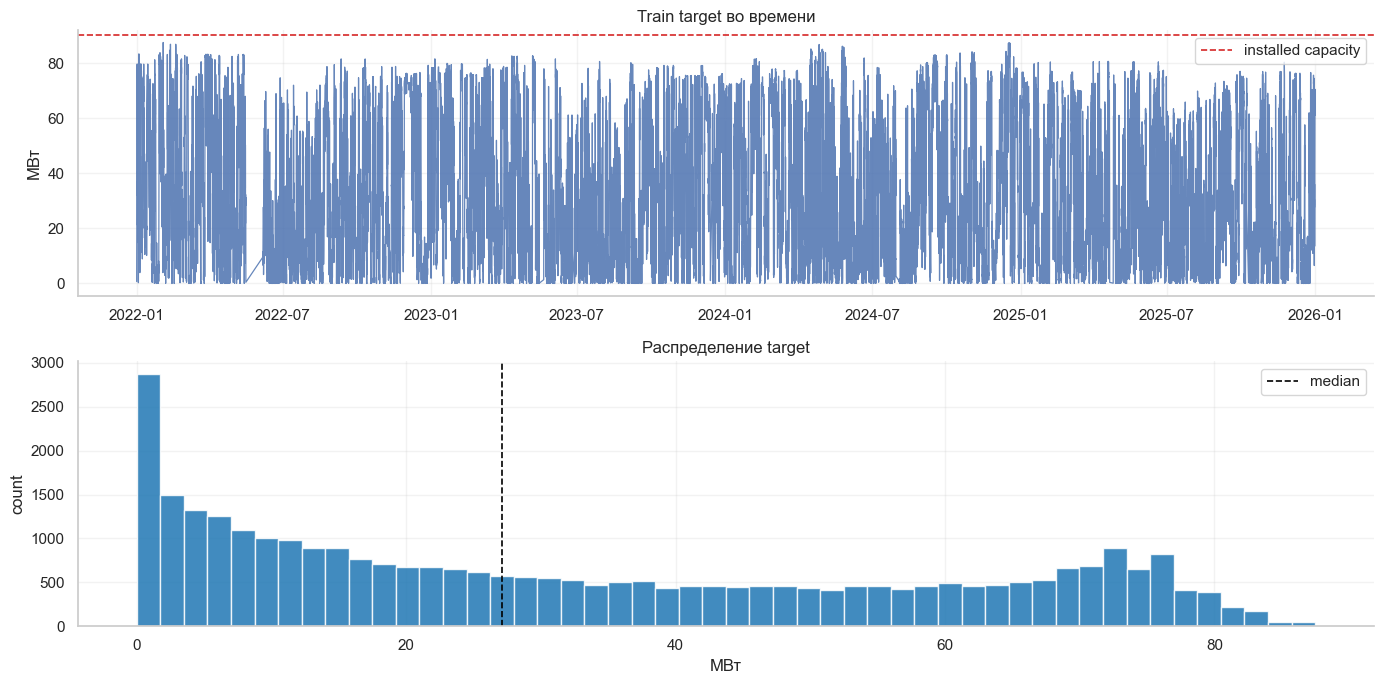

Saved plot: outputs\figures\01_target_time_and_distribution.png


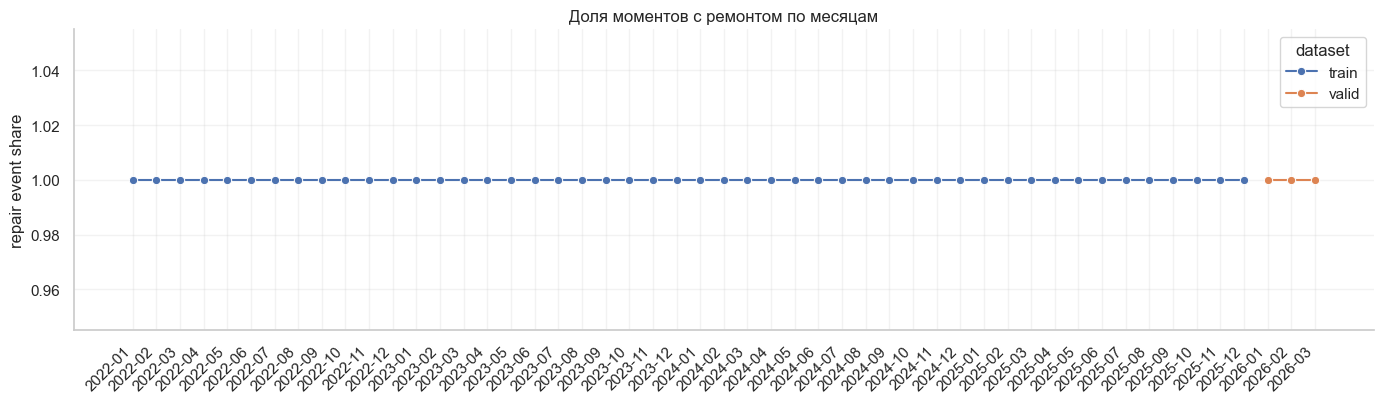

Saved plot: outputs\figures\02_repair_event_share_by_month.png


In [14]:
display(Markdown(
    "### 1. Загрузка данных\n\n"
    "Нормализуем имена ключевых колонок и сразу проверяем покрытие, target и ремонты."
))

if not TRAIN_PATH.exists():
    raise FileNotFoundError(f"Не найден train-файл: {TRAIN_PATH}")

if not VALID_PATH.exists():
    raise FileNotFoundError(f"Не найден valid-файл: {VALID_PATH}")

train_raw = pd.read_csv(TRAIN_PATH)
valid_raw = pd.read_csv(VALID_PATH)

target_col = None
for col in TARGET_CANDIDATES:
    if col in train_raw.columns and col not in valid_raw.columns:
        target_col = col
        break

if target_col is None:
    diff_cols = [col for col in train_raw.columns if col not in valid_raw.columns]
    if len(diff_cols) == 0:
        raise ValueError("Не найден target.")
    target_col = diff_cols[0]

datetime_col = None
for col in DATETIME_CANDIDATES:
    if col in train_raw.columns and col in valid_raw.columns:
        datetime_col = col
        break

if datetime_col is None:
    raise ValueError("Не найдена datetime-колонка.")

repair_col = None
for col in REPAIR_CANDIDATES:
    if col in train_raw.columns and col in valid_raw.columns:
        repair_col = col
        break

if repair_col is None:
    common_cols = [col for col in train_raw.columns if col in valid_raw.columns]
    repair_col = common_cols[-1]

train = train_raw.rename(
    columns={
        datetime_col: "datetime",
        target_col: "target",
        repair_col: "turbines_in_repair",
    }
).copy()

valid = valid_raw.rename(
    columns={
        datetime_col: "datetime",
        repair_col: "turbines_in_repair",
    }
).copy()

duplicate_rows = []
if not train.columns.is_unique:
    duplicate_rows.append({"dataset": "train", "duplicated_columns": train.columns[train.columns.duplicated()].tolist()})
    train = train.loc[:, ~train.columns.duplicated()].copy()

if not valid.columns.is_unique:
    duplicate_rows.append({"dataset": "valid", "duplicated_columns": valid.columns[valid.columns.duplicated()].tolist()})
    valid = valid.loc[:, ~valid.columns.duplicated()].copy()

train["datetime"] = pd.to_datetime(train["datetime"], errors="coerce")
valid["datetime"] = pd.to_datetime(valid["datetime"], errors="coerce")

train["row_id"] = np.arange(len(train))
valid["row_id"] = np.arange(len(valid))

train["source"] = "train"
valid["source"] = "valid"

train = train.sort_values("datetime").reset_index(drop=True)
valid = valid.sort_values("datetime").reset_index(drop=True)

column_mapping = pd.DataFrame([
    {"role": "datetime", "raw_column": datetime_col, "normalized_column": "datetime"},
    {"role": "target", "raw_column": target_col, "normalized_column": "target"},
    {"role": "repair_count", "raw_column": repair_col, "normalized_column": "turbines_in_repair"},
])
display(column_mapping)

overview_rows = []
for dataset_name, frame in [("train", train), ("valid", valid)]:
    dt = pd.to_datetime(frame["datetime"], errors="coerce")
    row = {
        "dataset": dataset_name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "datetime_start": dt.min(),
        "datetime_end": dt.max(),
        "duplicate_datetime_rows": int(dt.duplicated().sum()),
        "memory_mb": frame.memory_usage(deep=True).sum() / 1e6,
    }
    if "target" in frame.columns:
        y = pd.to_numeric(frame["target"], errors="coerce")
        row.update({
            "target_mean": y.mean(),
            "target_std": y.std(),
            "target_min": y.min(),
            "target_p50": y.quantile(0.50),
            "target_p95": y.quantile(0.95),
            "target_max": y.max(),
            "target_missing_share": y.isna().mean(),
        })
    repair = pd.to_numeric(frame["turbines_in_repair"], errors="coerce")
    row["repair_event_share"] = (repair.fillna(0) > 0).mean()
    row["repair_mean_turbines"] = repair.mean()
    overview_rows.append(row)

display(pd.DataFrame(overview_rows))

missing_rows = []
for dataset_name, frame in [("train", train), ("valid", valid)]:
    missing_share = frame.isna().mean().sort_values(ascending=False)
    for feature, share in missing_share[missing_share > 0].head(14).items():
        missing_rows.append({
            "dataset": dataset_name,
            "feature": feature,
            "missing_share": share,
            "missing_count": int(frame[feature].isna().sum()),
        })

missing_report = pd.DataFrame(missing_rows)
if len(missing_report) > 0:
    display(Markdown("### Пропуски\n\nПоказаны колонки с наибольшей долей пропусков."))
    display(missing_report)

if duplicate_rows:
    display(Markdown("### Дубли колонок"))
    display(pd.DataFrame(duplicate_rows))

target_repair_summary = pd.DataFrame([
    {
        "metric": "target_zero_share",
        "value": (pd.to_numeric(train["target"], errors="coerce").fillna(0) <= 1e-9).mean(),
    },
    {
        "metric": "target_above_capacity_share",
        "value": (pd.to_numeric(train["target"], errors="coerce") > INSTALLED_CAPACITY_MW).mean(),
    },
    {
        "metric": "repair_event_share_train",
        "value": (pd.to_numeric(train["turbines_in_repair"], errors="coerce").fillna(0) > 0).mean(),
    },
    {
        "metric": "repair_event_share_valid",
        "value": (pd.to_numeric(valid["turbines_in_repair"], errors="coerce").fillna(0) > 0).mean(),
    },
])
display(target_repair_summary)

if PLOT_RESEARCH_OUTPUTS:
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=False)
    axes[0].plot(train["datetime"], train["target"], linewidth=0.9, alpha=0.85)
    axes[0].axhline(INSTALLED_CAPACITY_MW, linestyle="--", linewidth=1.2, color="tab:red", label="installed capacity")
    axes[0].set_title("Train target во времени")
    axes[0].set_ylabel("МВт")
    axes[0].legend()

    axes[1].hist(train["target"].dropna(), bins=50, alpha=0.85, color="tab:blue")
    axes[1].axvline(train["target"].median(), linestyle="--", linewidth=1.2, color="black", label="median")
    axes[1].set_title("Распределение target")
    axes[1].set_xlabel("МВт")
    axes[1].set_ylabel("count")
    axes[1].legend()
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "01_target_time_and_distribution.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

    repair_compare = pd.concat([
        train[["datetime", "turbines_in_repair"]].assign(dataset="train"),
        valid[["datetime", "turbines_in_repair"]].assign(dataset="valid"),
    ], ignore_index=True)
    repair_compare["repair_event"] = pd.to_numeric(repair_compare["turbines_in_repair"], errors="coerce").fillna(0) > 0
    repair_by_month = (
        repair_compare
        .assign(month=repair_compare["datetime"].dt.to_period("M").astype(str))
        .groupby(["dataset", "month"], as_index=False)["repair_event"]
        .mean()
    )
    plt.figure(figsize=(14, 4.2))
    sns.lineplot(data=repair_by_month, x="month", y="repair_event", hue="dataset", marker="o")
    plt.xticks(rotation=45, ha="right")
    plt.title("Доля моментов с ремонтом по месяцам")
    plt.ylabel("repair event share")
    plt.xlabel("")
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "02_repair_event_share_by_month.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

In [15]:
sanity_rows = []
for name, frame in [("train", train), ("valid", valid)]:
    row = {
        "dataset": name,
        "rows": frame.shape[0],
        "columns": frame.shape[1],
        "duplicate_rows": int(frame.duplicated().sum()),
        "datetime_min": frame["datetime"].min() if "datetime" in frame.columns else pd.NaT,
        "datetime_max": frame["datetime"].max() if "datetime" in frame.columns else pd.NaT,
        "missing_total": int(frame.isna().sum().sum()),
    }
    if "target" in frame.columns:
        row.update({
            "target_min": pd.to_numeric(frame["target"], errors="coerce").min(),
            "target_mean": pd.to_numeric(frame["target"], errors="coerce").mean(),
            "target_max": pd.to_numeric(frame["target"], errors="coerce").max(),
        })
    sanity_rows.append(row)

sanity_report = pd.DataFrame(sanity_rows)
display(sanity_report)

key_missing_cols = [
    c for c in ["target", "wind_speed_80m", "wind_speed_120m", "wind_direction_120m", "turbines_in_repair"]
    if c in train.columns or c in valid.columns
]
missing_report = pd.concat([
    train[key_missing_cols].isna().mean().rename("train_missing_share"),
    valid[[c for c in key_missing_cols if c in valid.columns]].isna().mean().rename("valid_missing_share"),
], axis=1)
display(missing_report)


,dataset,rows,columns,duplicate_rows,datetime_min,datetime_max,missing_total,target_min,target_mean,target_max
0,train,32434,38,0,2022-01-01,2025-12-31 23:00:00,13672,0.001,33.005746,87.475
1,valid,2126,37,0,2026-01-01,2026-03-31 23:00:00,0,NaN,NaN,NaN


,train_missing_share,valid_missing_share
target,0.0,NaN
wind_speed_80m,0.0,0.0
wind_speed_120m,0.0,0.0
wind_direction_120m,0.0,0.0
turbines_in_repair,0.0,0.0


## 2. Базовые признаки: календарь, ветер, доступная мощность, физическая power curve

In [16]:
SPEED_COLS_RAW = [
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
]

DIRECTION_COLS_RAW = [
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
]

SHEAR_HEIGHT_PAIRS = [
    (10, 80),
    (80, 120),
    (120, 180),
    (80, 180),
    (10, 120),
]

DIRECTION_SECTOR_HEIGHTS = [80, 120, 180]
DIRECTION_SECTOR_COUNTS = [8, 16]

CAP_SPEED_HEIGHT = 120
CAP_SPEED_VALUE = 13

WEATHER_FEATURE_BLOCKS = {
    "shear": [],
    "cap13": [],
    "direction_sectors": [],
    "nasa_openm_disagreement": [],
    "isotonic": [],
    "density_humidity": [],
}

In [17]:
print("2. Генерация базовых признаков...")

full = pd.concat([train, valid], ignore_index=True, sort=False)
full = full.sort_values("datetime").reset_index(drop=True)


2. Генерация базовых признаков...


In [18]:
# ------------------------------------------------------------
# Время


In [19]:
# ------------------------------------------------------------

full["month"] = full["datetime"].dt.month
full["hour_of_day"] = full["datetime"].dt.hour
full["dayofyear"] = full["datetime"].dt.dayofyear
full["dayofweek"] = full["datetime"].dt.dayofweek

full["hour_sin"] = np.sin(2 * np.pi * full["hour_of_day"] / 24)
full["hour_cos"] = np.cos(2 * np.pi * full["hour_of_day"] / 24)

full["month_sin"] = np.sin(2 * np.pi * full["month"] / 12)
full["month_cos"] = np.cos(2 * np.pi * full["month"] / 12)

full["dayofyear_sin"] = np.sin(2 * np.pi * full["dayofyear"] / 366)
full["dayofyear_cos"] = np.cos(2 * np.pi * full["dayofyear"] / 366)


In [20]:
# ------------------------------------------------------------
# Ветер


In [21]:
# ------------------------------------------------------------

speed_cols = [c for c in SPEED_COLS_RAW if c in full.columns]
direction_cols = [c for c in DIRECTION_COLS_RAW if c in full.columns]

for col in speed_cols:
    full[f"{col}_sq"] = full[col] ** 2
    full[f"{col}_cube"] = full[col] ** 3

for col in direction_cols:
    suffix = col.replace("wind_direction_", "")
    angle = np.deg2rad(full[col] * 1000)
    full[f"wind_dir_{suffix}_sin"] = np.sin(angle)
    full[f"wind_dir_{suffix}_cos"] = np.cos(angle)

if "wind_speed_120m" in full.columns:
    full["ws_120_cube"] = full["wind_speed_120m"] ** 3

if {"wind_speed_120m", "wind_speed_80m"}.issubset(full.columns):
    full["ws_diff_120_80"] = full["wind_speed_120m"] - full["wind_speed_80m"]
    full["ws_ratio_120_80"] = full["wind_speed_120m"] / (full["wind_speed_80m"] + EPS)

if {"wind_speed_180m", "wind_speed_120m"}.issubset(full.columns):
    full["ws_diff_180_120"] = full["wind_speed_180m"] - full["wind_speed_120m"]

if {"wind_gusts_10m", "wind_speed_10m"}.issubset(full.columns):
    full["gust_ratio_10m"] = full["wind_gusts_10m"] / (full["wind_speed_10m"] + EPS)


In [22]:
# ------------------------------------------------------------
# Сухая плотность воздуха и density-corrected speed


In [23]:
# ------------------------------------------------------------

required_density_cols = {"temperature_80m", "temperature_120m", "pressure_msl"}
if required_density_cols.issubset(full.columns):
    temperature_mean = 0.5 * (full["temperature_80m"] + full["temperature_120m"])
    temperature_mean_k = temperature_mean + 273.15
    pressure_pa = full["pressure_msl"] * 100

    full["air_density"] = pressure_pa / (287.05 * temperature_mean_k)
    full["density_ratio"] = (full["air_density"] / AIR_DENSITY_REF).clip(0.75, 1.30)

    WEATHER_FEATURE_BLOCKS["density_humidity"] += [
        "air_density",
        "density_ratio",
    ]

    for height in [80, 120]:
        speed_col = f"wind_speed_{height}m"
        if speed_col in full.columns:
            full[f"wind_speed_{height}m_density_corrected"] = (
                full[speed_col] * (full["density_ratio"] ** (1 / 3))
            )
            full[f"wind_power_density_{height}m"] = (
                0.5 * full["air_density"] * full[speed_col] ** 3
            )

            WEATHER_FEATURE_BLOCKS["density_humidity"] += [
                f"wind_speed_{height}m_density_corrected",
                f"wind_power_density_{height}m",
            ]

for col in WEATHER_FEATURE_BLOCKS["density_humidity"]:
    if col in full.columns:
        full[col] = full[col].replace([np.inf, -np.inf], np.nan)


In [24]:
# ------------------------------------------------------------
# Доступность ВЭС


In [25]:
# ------------------------------------------------------------

full["turbines_in_repair"] = pd.to_numeric(full["turbines_in_repair"], errors="coerce")

availability = (
    (TURBINES_TOTAL - full["turbines_in_repair"])
    .clip(0, TURBINES_TOTAL)
    / TURBINES_TOTAL
)

full["available_capacity_mw"] = availability * INSTALLED_CAPACITY_MW


In [26]:
# ------------------------------------------------------------
# Теоретическая кривая мощности


In [27]:
# ------------------------------------------------------------

for height in [80, 120]:
    speed_col = f"wind_speed_{height}m"

    if speed_col in full.columns:
        speed = full[speed_col].clip(lower=0)

        curve = (
            (speed ** 3 - CUT_IN_SPEED ** 3)
            / (RATED_SPEED ** 3 - CUT_IN_SPEED ** 3)
        ).clip(0, 1)

        curve = curve.where(speed >= CUT_IN_SPEED, 0)
        curve = curve.where(speed < CUT_OUT_SPEED, 0)

        full[f"p_theory_{height}"] = INSTALLED_CAPACITY_MW * curve * availability

if {"p_theory_80", "p_theory_120"}.issubset(full.columns):
    full["p_theory_mean_80_120"] = 0.5 * (full["p_theory_80"] + full["p_theory_120"])


In [28]:
# ------------------------------------------------------------
# Wind profile block: shear


In [29]:
# ------------------------------------------------------------

def add_shear_feature(df, low_h, high_h):
    low_col = f"wind_speed_{low_h}m"
    high_col = f"wind_speed_{high_h}m"
    out_col = f"shear_{low_h}_{high_h}"

    if low_col in df.columns and high_col in df.columns:
        df[out_col] = (
            np.log((df[high_col].clip(lower=EPS)) / (df[low_col].clip(lower=EPS)))
            / np.log(high_h / low_h)
        )
        df[out_col] = df[out_col].replace([np.inf, -np.inf], np.nan)
        WEATHER_FEATURE_BLOCKS["shear"].append(out_col)

for low_h, high_h in SHEAR_HEIGHT_PAIRS:
    add_shear_feature(full, low_h, high_h)


In [30]:
# ------------------------------------------------------------
# cap13


In [31]:
# ------------------------------------------------------------

cap_col = f"wind_speed_{CAP_SPEED_HEIGHT}m"
if cap_col in full.columns:
    base = f"wind{CAP_SPEED_HEIGHT}_cap{CAP_SPEED_VALUE}"

    full[f"{base}_clipped"] = full[cap_col].clip(upper=CAP_SPEED_VALUE)
    full[f"{base}_above"] = (full[cap_col] - CAP_SPEED_VALUE).clip(lower=0)
    full[f"{base}_is_above"] = (full[cap_col] > CAP_SPEED_VALUE).astype(int)
    full[f"{base}_clipped_cube"] = full[f"{base}_clipped"] ** 3

    WEATHER_FEATURE_BLOCKS["cap13"] += [
        f"{base}_clipped",
        f"{base}_above",
        f"{base}_is_above",
        f"{base}_clipped_cube",
    ]


In [32]:
# ------------------------------------------------------------
# direction sectors


In [33]:
# ------------------------------------------------------------

for height in DIRECTION_SECTOR_HEIGHTS:
    col = f"wind_direction_{height}m"

    if col in full.columns:
        deg = (full[col] * 1000) % 360

        for n_sec in DIRECTION_SECTOR_COUNTS:
            sec_col = f"wind_dir_{height}m_sector_{n_sec}"

            sector = np.floor(deg / (360 / n_sec))
            sector = (
                sector
                .replace([np.inf, -np.inf], np.nan)
                .fillna(-1)
                .clip(-1, n_sec - 1)
                .astype(int)
            )

            full[sec_col] = sector
            WEATHER_FEATURE_BLOCKS["direction_sectors"].append(sec_col)


In [34]:
# ------------------------------------------------------------
# NASA/OpenM disagreement


In [35]:
# ------------------------------------------------------------
# Согласованность погодных источников
# ------------------------------------------------------------

for openm_col, nasa_col, new_col in [
    ("wind_speed_10m", "WS10M", "ws10_openm_minus_nasa"),
    ("wind_speed_80m", "WS50M", "ws80_openm_minus_nasa50"),
    ("pressure_msl", "PS", "pressure_msl_minus_ps"),
    ("temperature_80m", "T2M", "temp80_minus_t2m"),
]:
    if openm_col in full.columns and nasa_col in full.columns:
        full[new_col] = full[openm_col] - full[nasa_col]
        full[new_col] = full[new_col].replace([np.inf, -np.inf], np.nan)
        WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"].append(new_col)

if "wind_direction_10m" in full.columns and "WD10M" in full.columns:
    openm_deg = (full["wind_direction_10m"] * 1000) % 360
    nasa_deg = full["WD10M"] % 360

    diff = ((openm_deg - nasa_deg + 180) % 360) - 180
    full["wd10_openm_minus_nasa_circular"] = diff.replace([np.inf, -np.inf], np.nan)

    WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"].append("wd10_openm_minus_nasa_circular")

for block_name in WEATHER_FEATURE_BLOCKS:
    WEATHER_FEATURE_BLOCKS[block_name] = sorted(list(dict.fromkeys(WEATHER_FEATURE_BLOCKS[block_name])))

diff_rows = []
for col in WEATHER_FEATURE_BLOCKS["nasa_openm_disagreement"]:
    s = pd.to_numeric(full[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    diff_rows.append({
        "signal": col,
        "mean": s.mean(),
        "std": s.std(),
        "p05": s.quantile(0.05),
        "p50": s.quantile(0.50),
        "p95": s.quantile(0.95),
        "missing_share": s.isna().mean(),
    })

display(Markdown(
    "### Согласованность NASA и Open-Meteo\n\n"
    "Сводка показывает величину расхождений между погодными источниками по скорости, давлению, температуре и направлению."
))
display(pd.DataFrame(diff_rows))

### Согласованность NASA и Open-Meteo

Сводка показывает величину расхождений между погодными источниками по скорости, давлению, температуре и направлению.

,signal,mean,std,p05,p50,p95,missing_share
0,pressure_msl_minus_ps,914.978653,6.765006,904.95,914.33,926.79,0.0
1,temp80_minus_t2m,-0.265495,2.198786,-4.00,-0.16,3.21,0.0
2,wd10_openm_minus_nasa_circular,-11.021638,34.355118,-67.60,-8.00,31.30,0.0
3,ws10_openm_minus_nasa,-1.159373,1.418901,-3.44,-1.17,1.20,0.0
4,ws80_openm_minus_nasa50,-0.513107,1.571829,-3.03,-0.52,2.08,0.0


## 3. Временное сглаживание и локальный NWP-контекст

In [36]:
EWM_SPANS = {
    "3h": 3,
    "5h": 5,
    "7h": 7
}

EMA_SOURCE_COLS = [
    "wind_speed_120m_cube",
    "p_theory_80",
    "p_theory_120",
    "wind_power_density_120m",
]

NWP_SHIFTS = [ -6, -3, -2, -1, 1, 2, 3, 6]

NWP_BASE_COLS = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_cube",
    "wind_speed_120m_density_corrected",
    "p_theory_120",
    "wind_power_density_120m",
]

In [37]:
print("3. EMA и NWP-соседи...")

full = full.sort_values("datetime").reset_index(drop=True)
time_indexed = full.set_index("datetime")

ema_cols = [c for c in EMA_SOURCE_COLS if c in full.columns]

for col in ema_cols:
    for window_str, span_val in EWM_SPANS.items():
        full[f"{col}_smooth_{window_str}"] = (
            time_indexed[col]
            .ewm(span=span_val, min_periods=1)
            .mean()
            .reindex(full["datetime"])
            .to_numpy()
        )

    full[f"{col}_minus_smooth_3h"] = full[col] - full[f"{col}_smooth_3h"]

nwp_base_cols = [c for c in NWP_BASE_COLS if c in full.columns]

for col in nwp_base_cols:
    for shift_hours in NWP_SHIFTS:
        shifted_datetime = full["datetime"] + pd.to_timedelta(shift_hours, unit="h")
        label = f"plus_{shift_hours}h" if shift_hours > 0 else f"minus_{abs(shift_hours)}h"

        full[f"{col}_nwp_{label}"] = (
            time_indexed[col]
            .reindex(shifted_datetime)
            .to_numpy()
        )

ema_effect_rows = []
for col in ema_cols[:6]:
    smooth_col = f"{col}_smooth_3h"
    diff_col = f"{col}_minus_smooth_3h"
    if smooth_col in full.columns and diff_col in full.columns:
        raw = pd.to_numeric(full[col], errors="coerce")
        smooth = pd.to_numeric(full[smooth_col], errors="coerce")
        delta = pd.to_numeric(full[diff_col], errors="coerce")
        ema_effect_rows.append({
            "signal": col,
            "raw_std": raw.std(),
            "smooth_3h_std": smooth.std(),
            "raw_minus_smooth_3h_std": delta.std(),
            "raw_missing_share": raw.isna().mean(),
        })

display(Markdown(
    "### EMA и NWP-соседи\n\n"
    "EMA сглаживает погодный сигнал, а соседние forecast-horizon значения дают локальный контекст прогноза."
))
display(pd.DataFrame(ema_effect_rows))

3. EMA и NWP-соседи...


### EMA и NWP-соседи

EMA сглаживает погодный сигнал, а соседние forecast-horizon значения дают локальный контекст прогноза.

,signal,raw_std,smooth_3h_std,raw_minus_smooth_3h_std,raw_missing_share
0,wind_speed_120m_cube,861.438455,833.861118,152.901163,0.0
1,p_theory_80,20.547748,19.977654,3.398979,0.0
2,p_theory_120,25.337215,24.561681,4.399293,0.0
3,wind_power_density_120m,542.669454,525.773164,95.012834,0.0


## 4. Empirical power curve, обученная только по train

In [38]:
EMPIRICAL_SPEED_HEIGHTS = [80, 120]
EMPIRICAL_SPEED_BINS = np.arange(0, 26.5, 0.5)
EMPIRICAL_MIN_BIN_COUNT = 20
EMPIRICAL_CF_MAX = 1.15

# Диагностика power curve использует те же бины, что и empirical power curve.
POWER_CURVE_SPEED_BINS = EMPIRICAL_SPEED_BINS
POWER_CURVE_MIN_BIN_COUNT = EMPIRICAL_MIN_BIN_COUNT

4. Эмпирическая кривая мощности...


### Эмпирическая кривая мощности

Сравниваем физическую и эмпирическую кривые по train: ошибка, bias и форма зависимости от скорости ветра.

,curve,mae_train,bias_train,pred_mean
0,p_theory_120,12.154123,-8.305275,24.700471
1,p_empirical_120,9.705588,-0.576407,32.429339
2,p_empirical_iso_120,9.702282,-0.603745,32.402001
3,p_empirical_mean_80_120,9.473041,-0.698119,32.307627


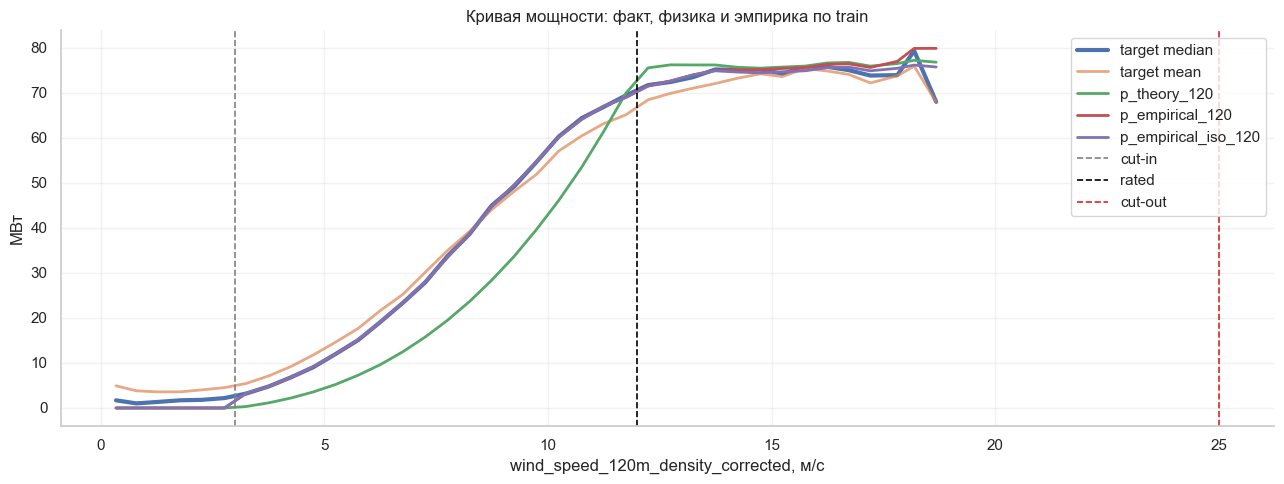

Saved plot: outputs\figures\04_empirical_power_curve.png


In [39]:
print("4. Эмпирическая кривая мощности...")

train_base = (
    full[full["source"].eq("train")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

valid_base = (
    full[full["source"].eq("valid")]
    .copy()
    .sort_values("datetime")
    .reset_index(drop=True)
)

def add_empirical_power_features(frame, reference):
    frame = frame.copy()
    reference = reference.copy()

    ref_available = reference["available_capacity_mw"].clip(lower=1.0)
    reference["cf_available"] = (reference["target"] / ref_available).clip(0, EMPIRICAL_CF_MAX)

    iso_cols = []

    for height in EMPIRICAL_SPEED_HEIGHTS:
        speed_col = f"wind_speed_{height}m_density_corrected"

        if speed_col not in frame.columns or speed_col not in reference.columns:
            print(f"WARN: нет {speed_col}, пропускаю p_empirical_{height}")
            continue

        ref = reference[[speed_col, "cf_available"]].dropna().copy()
        ref["bin_id"] = pd.cut(ref[speed_col], bins=EMPIRICAL_SPEED_BINS, labels=False)

        curve = (
            ref.groupby("bin_id", as_index=False)
            .agg(
                cf=("cf_available", "median"),
                n=("cf_available", "size"),
            )
        )

        curve = curve[curve["n"] >= EMPIRICAL_MIN_BIN_COUNT].copy()
        curve["speed"] = EMPIRICAL_SPEED_BINS[curve["bin_id"].astype(int)] + 0.25
        curve = curve.sort_values("speed")

        if len(curve) == 0:
            frame[f"p_empirical_{height}"] = 0.0
            frame[f"cf_empirical_{height}"] = 0.0
            frame[f"p_empirical_iso_{height}"] = 0.0
            frame[f"cf_empirical_iso_{height}"] = 0.0

            iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]
            continue

        cf_monotonic = np.maximum.accumulate(curve["cf"].to_numpy())

        x = np.r_[0.0, curve["speed"].to_numpy(), CUT_OUT_SPEED]
        y = np.r_[0.0, cf_monotonic, cf_monotonic[-1]]

        unique_x, unique_idx = np.unique(x, return_index=True)
        unique_y = y[unique_idx]

        interpolator = PchipInterpolator(unique_x, unique_y, extrapolate=True)

        speed_eval = frame[speed_col].clip(0, CUT_OUT_SPEED)

        empirical_cf = np.clip(interpolator(speed_eval), 0, EMPIRICAL_CF_MAX)
        empirical_cf = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf)
        empirical_cf = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf)

        frame[f"p_empirical_{height}"] = empirical_cf * frame["available_capacity_mw"]
        frame[f"cf_empirical_{height}"] = empirical_cf

        iso = IsotonicRegression(
            y_min=0.0,
            y_max=EMPIRICAL_CF_MAX,
            increasing=True,
            out_of_bounds="clip",
        )

        iso.fit(curve["speed"].to_numpy(), curve["cf"].to_numpy())

        empirical_cf_iso = np.clip(iso.predict(speed_eval), 0, EMPIRICAL_CF_MAX)
        empirical_cf_iso = np.where(frame[speed_col] < CUT_IN_SPEED, 0, empirical_cf_iso)
        empirical_cf_iso = np.where(frame[speed_col] >= CUT_OUT_SPEED, 0, empirical_cf_iso)

        frame[f"p_empirical_iso_{height}"] = empirical_cf_iso * frame["available_capacity_mw"]
        frame[f"cf_empirical_iso_{height}"] = empirical_cf_iso

        iso_cols += [f"p_empirical_iso_{height}", f"cf_empirical_iso_{height}"]

    if {"p_empirical_80", "p_empirical_120"}.issubset(frame.columns):
        frame["p_empirical_mean_80_120"] = 0.5 * (
            frame["p_empirical_80"] + frame["p_empirical_120"]
        )

    if {"p_empirical_iso_80", "p_empirical_iso_120"}.issubset(frame.columns):
        frame["p_empirical_iso_mean_80_120"] = 0.5 * (
            frame["p_empirical_iso_80"] + frame["p_empirical_iso_120"]
        )
        iso_cols.append("p_empirical_iso_mean_80_120")

    if {"p_empirical_120", "p_theory_120"}.issubset(frame.columns):
        frame["p_empirical_minus_theory_120"] = frame["p_empirical_120"] - frame["p_theory_120"]

    return frame, sorted(list(dict.fromkeys(iso_cols)))


train_fe, iso_train_cols = add_empirical_power_features(train_base, train_base)
valid_fe, iso_valid_cols = add_empirical_power_features(valid_base, train_base)

WEATHER_FEATURE_BLOCKS["isotonic"] = sorted(
    list(set(iso_train_cols).intersection(set(iso_valid_cols)))
)

empirical_quality_rows = []
for col in ["p_theory_120", "p_empirical_120", "p_empirical_iso_120", "p_empirical_mean_80_120"]:
    if col in train_fe.columns:
        y_true = pd.to_numeric(train_fe["target"], errors="coerce")
        y_pred = pd.to_numeric(train_fe[col], errors="coerce").clip(0, INSTALLED_CAPACITY_MW)
        mask = y_true.notna() & y_pred.notna()
        if mask.any():
            empirical_quality_rows.append({
                "curve": col,
                "mae_train": mean_absolute_error(y_true[mask], y_pred[mask]),
                "bias_train": float((y_pred[mask] - y_true[mask]).mean()),
                "pred_mean": y_pred[mask].mean(),
            })

display(Markdown(
    "### Эмпирическая кривая мощности\n\n"
    "Сравниваем физическую и эмпирическую кривые по train: ошибка, bias и форма зависимости от скорости ветра."
))
display(pd.DataFrame(empirical_quality_rows))

if PLOT_RESEARCH_OUTPUTS and {"wind_speed_120m_density_corrected", "target"}.issubset(train_fe.columns):
    plot_cols = ["wind_speed_120m_density_corrected", "target"]
    for col in ["p_theory_120", "p_empirical_120", "p_empirical_iso_120"]:
        if col in train_fe.columns:
            plot_cols.append(col)

    curve_tmp = train_fe[plot_cols].dropna().copy()
    curve_tmp["speed_bin"] = pd.cut(curve_tmp["wind_speed_120m_density_corrected"], bins=np.arange(0, 26.5, 0.5))
    curve_report_emp = (
        curve_tmp
        .groupby("speed_bin", observed=True)
        .agg(
            n=("target", "size"),
            speed_mean=("wind_speed_120m_density_corrected", "mean"),
            target_median=("target", "median"),
            target_mean=("target", "mean"),
            **{
                f"{col}_mean": (col, "mean")
                for col in plot_cols
                if col not in {"wind_speed_120m_density_corrected", "target"}
            },
        )
        .reset_index()
    )
    curve_report_emp = curve_report_emp[curve_report_emp["n"] >= EMPIRICAL_MIN_BIN_COUNT].copy()

    plt.figure(figsize=(13, 5))
    plt.plot(curve_report_emp["speed_mean"], curve_report_emp["target_median"], linewidth=3, label="target median")
    plt.plot(curve_report_emp["speed_mean"], curve_report_emp["target_mean"], linewidth=2, alpha=0.7, label="target mean")
    for col in ["p_theory_120_mean", "p_empirical_120_mean", "p_empirical_iso_120_mean"]:
        if col in curve_report_emp.columns:
            plt.plot(curve_report_emp["speed_mean"], curve_report_emp[col], linewidth=2, label=col.replace("_mean", ""))
    plt.axvline(CUT_IN_SPEED, linestyle="--", linewidth=1.2, color="gray", label="cut-in")
    plt.axvline(RATED_SPEED, linestyle="--", linewidth=1.2, color="black", label="rated")
    plt.axvline(CUT_OUT_SPEED, linestyle="--", linewidth=1.2, color="tab:red", label="cut-out")
    plt.title("Кривая мощности: факт, физика и эмпирика по train")
    plt.xlabel("wind_speed_120m_density_corrected, м/с")
    plt.ylabel("МВт")
    plt.legend()
    plt.tight_layout()
    plot_path = RESEARCH_PLOT_DIR / "04_empirical_power_curve.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)

if "p_empirical_mean_80_120" not in train_fe.columns:
    raise RuntimeError(
        "Не создалась p_empirical_mean_80_120. Проверь density-corrected признаки."
    )

## 5. Базовый список модельных признаков

In [40]:
RAW_FEATURE_COLS = [
    "month",
    "hour_of_day",
    "wind_speed_10m",
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_180m",
    "wind_direction_10m",
    "wind_direction_80m",
    "wind_direction_120m",
    "wind_direction_180m",
    "wind_gusts_10m",
    "temperature_80m",
    "temperature_120m",
    "pressure_msl",
    "rain",
    "showers",
    "snowfall",
    "cloud_cover_low",
    "turbines_in_repair",
]

PHYSICS_FEATURE_COLS = [
    "available_capacity_mw",
    "air_density",
    "density_ratio",
    "wind_power_density_80m",
    "wind_power_density_120m",
    "p_theory_80",
    "p_theory_120",
    "p_theory_mean_80_120",
    "p_empirical_80",
    "p_empirical_120",
    "p_empirical_mean_80_120",
    "p_empirical_minus_theory_120",
    "cf_empirical_80",
    "cf_empirical_120",
]

STABLE_BLOCKS = [
    "shear",
    "cap13",
    "direction_sectors",
    "nasa_openm_disagreement",
    "isotonic",
]

In [41]:
auto_cols = [
    col for col in train_fe.columns
    if (
        col.endswith("_sq")
        or col.endswith("_cube")
        or col.startswith("wind_dir_")
        or "_smooth_" in col
        or col.endswith("_minus_smooth_3h")
        or "_nwp_" in col
        or col.endswith("_density_corrected")
        or col.startswith("ws_")
        or col.startswith("gust_ratio")
        or col.startswith("dayofyear_")
    )
]

feature_candidates = RAW_FEATURE_COLS + PHYSICS_FEATURE_COLS + auto_cols

baseline_features = list(dict.fromkeys([
    c for c in feature_candidates
    if c in train_fe.columns and c in valid_fe.columns
]))

stable_extra_features = []
for block_name in STABLE_BLOCKS:
    stable_extra_features += WEATHER_FEATURE_BLOCKS.get(block_name, [])

stable_extra_features = list(dict.fromkeys([
    c for c in stable_extra_features
    if c in train_fe.columns and c in valid_fe.columns
]))

model_features_base = list(dict.fromkeys([
    c for c in baseline_features + stable_extra_features
    if c in train_fe.columns and c in valid_fe.columns
]))

shift_cols = [
    "wind_speed_80m",
    "wind_speed_120m",
    "wind_speed_120m_density_corrected",
    "temperature_80m",
    "pressure_msl",
    "turbines_in_repair",
]

shift_rows = []
for col in shift_cols:
    if col not in train_fe.columns or col not in valid_fe.columns:
        continue
    tr = pd.to_numeric(train_fe[col], errors="coerce")
    va = pd.to_numeric(valid_fe[col], errors="coerce")
    if tr.notna().sum() == 0 or va.notna().sum() == 0:
        continue
    pooled_std = np.sqrt((tr.std() ** 2 + va.std() ** 2) / 2)
    std_mean_delta = np.nan if pooled_std == 0 or not np.isfinite(pooled_std) else (va.mean() - tr.mean()) / pooled_std
    shift_rows.append({
        "signal": col,
        "train_mean": tr.mean(),
        "valid_mean": va.mean(),
        "mean_delta": va.mean() - tr.mean(),
        "std_mean_delta": std_mean_delta,
        "train_missing": tr.isna().mean(),
        "valid_missing": va.isna().mean(),
    })

shift_report = pd.DataFrame(shift_rows)
if len(shift_report) > 0:
    shift_report = shift_report.assign(abs_std_mean_delta=shift_report["std_mean_delta"].abs())
    shift_report = shift_report.sort_values("abs_std_mean_delta", ascending=False)

display(Markdown(
    "### Train-vs-valid сдвиг по ключевой погоде\n\n"
    "Проверяем, насколько valid отличается от train по основным физическим сигналам."
))
display(shift_report)

### Train-vs-valid сдвиг по ключевой погоде

Проверяем, насколько valid отличается от train по основным физическим сигналам.

,signal,train_mean,valid_mean,mean_delta,std_mean_delta,train_missing,valid_missing,abs_std_mean_delta
3,temperature_80m,12.264694,0.774459,-11.490235,-1.354083,0.0,0.0,1.354083
5,turbines_in_repair,4.021798,3.315146,-0.706652,-0.918832,0.0,0.0,0.918832
2,wind_speed_120m_density_corrected,7.459721,8.174622,0.714901,0.211449,0.0,0.0,0.211449
1,wind_speed_120m,7.420251,8.031176,0.610925,0.182888,0.0,0.0,0.182888
0,wind_speed_80m,6.549474,6.841326,0.291852,0.102259,0.0,0.0,0.102259
4,pressure_msl,1016.369853,1016.633396,0.263543,0.031638,0.0,0.0,0.031638


## 6.1 Train/valid feature alignment

Перед моделированием фиксируем итоговый список признаков и проверяем, что каждая колонка присутствует в обеих таблицах.

In [42]:
feature_alignment_report = pd.DataFrame([{
    "n_model_features": len(model_features_base),
    "missing_in_train": len([c for c in model_features_base if c not in train_fe.columns]),
    "missing_in_valid": len([c for c in model_features_base if c not in valid_fe.columns]),
}])
display(feature_alignment_report)

if SAVE_DIAGNOSTIC_ARTIFACTS:
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"feature": model_features_base}).to_csv(LOG_DIR / "base_model_features.csv", index=False)


,n_model_features,missing_in_train,missing_in_valid
0,147,0,0


## 6. Геометрия ВЭС и wake-risk

In [43]:

# ============================================================
# Геометрия ВЭС — параметры заданы в глобальных настройках
# ============================================================

print("N_LAYOUT_CLUSTERS:", N_LAYOUT_CLUSTERS)
print("WAKE_DIRECTION_STEP_DEG:", WAKE_DIRECTION_STEP_DEG)
print("BEST_WAKE_FEATURE:", BEST_WAKE_FEATURE)


N_LAYOUT_CLUSTERS: 4
WAKE_DIRECTION_STEP_DEG: 5
BEST_WAKE_FEATURE: layout_wake_risk_scalar_120m


ГЕОМЕТРИЯ ВЭС
Турбин: 26
Среднее ближайшее расстояние: 343.0 м
Медианное ближайшее расстояние: 353.6 м


Главная ось ВЭС: 9.30° / 189.30°
Доля объяснённой дисперсии PCA: [0.69031765 0.30968235]


,cluster_id,cluster_axis_compass_deg,cluster_axis_evr,n
0,0,1.049124,0.999860,6
1,1,0.071119,0.999975,8
2,2,88.689012,0.831549,6
3,3,333.710799,0.965362,6


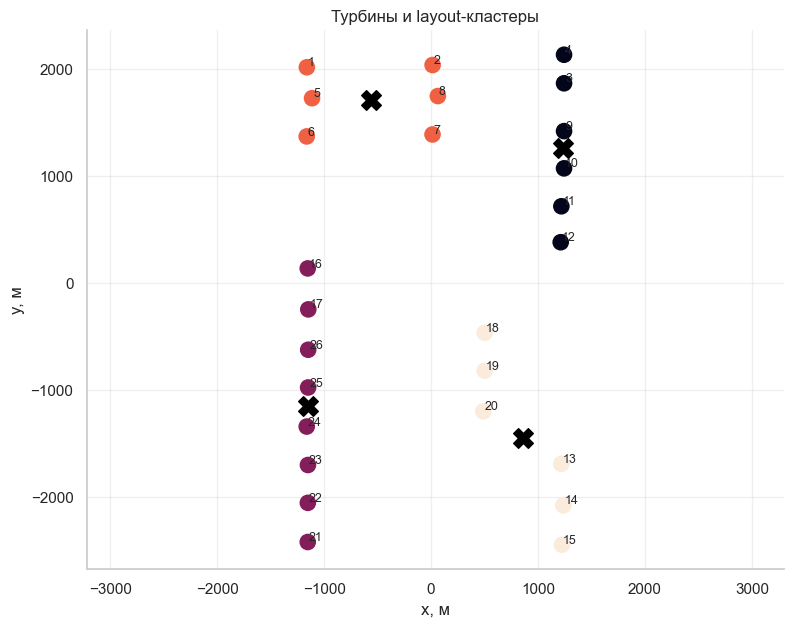

In [44]:
print("=" * 90)
print("ГЕОМЕТРИЯ ВЭС")
print("=" * 90)

if not TURBINE_COORDS_PATH.exists():
    raise FileNotFoundError(
        f"Не найден {TURBINE_COORDS_PATH}. Положи координаты турбин в map/data/wind_farm_coords.csv."
    )

turbines = pd.read_csv(TURBINE_COORDS_PATH)

if "turbine_id" not in turbines.columns:
    turbines["turbine_id"] = np.arange(1, len(turbines) + 1)

if not {"lat", "lon"}.issubset(turbines.columns):
    raise ValueError("В файле турбин должны быть колонки lat и lon.")

lat0 = turbines["lat"].mean()
lon0 = turbines["lon"].mean()

meters_per_deg_lat = 111_320
meters_per_deg_lon = 111_320 * np.cos(np.deg2rad(lat0))

turbines["x_m"] = (turbines["lon"] - lon0) * meters_per_deg_lon
turbines["y_m"] = (turbines["lat"] - lat0) * meters_per_deg_lat

XY = turbines[["x_m", "y_m"]].to_numpy()

D = squareform(pdist(XY))
D_near = D + np.eye(len(D)) * 10**9
nearest_dist = D_near.min(axis=1)

print("Турбин:", len(turbines))
print(f"Среднее ближайшее расстояние: {nearest_dist.mean():.1f} м")
print(f"Медианное ближайшее расстояние: {np.median(nearest_dist):.1f} м")

kmeans_layout = KMeans(
    n_clusters=N_LAYOUT_CLUSTERS,
    random_state=RANDOM_STATE,
    n_init=LAYOUT_KMEANS_N_INIT,
)

turbines["layout_cluster"] = kmeans_layout.fit_predict(XY)

cluster_centers = pd.DataFrame(
    kmeans_layout.cluster_centers_,
    columns=["x_m", "y_m"],
)
cluster_centers["cluster_id"] = np.arange(len(cluster_centers))

pca_layout = PCA(n_components=2)
pca_layout.fit(XY)

main_axis = pca_layout.components_[0]
axis_angle_xy_deg = (np.rad2deg(np.arctan2(main_axis[1], main_axis[0])) + 360) % 360
farm_axis_compass_deg = (90 - axis_angle_xy_deg) % 360

print(f"Главная ось ВЭС: {farm_axis_compass_deg:.2f}° / {(farm_axis_compass_deg + 180) % 360:.2f}°")
print("Доля объяснённой дисперсии PCA:", pca_layout.explained_variance_ratio_)

cluster_axis_rows = []

for cl in sorted(turbines["layout_cluster"].unique()):
    part = turbines[turbines["layout_cluster"].eq(cl)].copy()
    XYc = part[["x_m", "y_m"]].to_numpy()

    if len(part) >= 2:
        pcac = PCA(n_components=2)
        pcac.fit(XYc)
        axis = pcac.components_[0]
        axis_xy = (np.rad2deg(np.arctan2(axis[1], axis[0])) + 360) % 360
        axis_compass = (90 - axis_xy) % 360
        evr = pcac.explained_variance_ratio_[0]
    else:
        axis_compass = np.nan
        evr = np.nan

    cluster_axis_rows.append({
        "cluster_id": cl,
        "cluster_axis_compass_deg": axis_compass,
        "cluster_axis_evr": evr,
        "n": len(part),
    })

cluster_axis_df = pd.DataFrame(cluster_axis_rows)
display(cluster_axis_df)

plt.figure(figsize=(9, 7))
plt.scatter(turbines["x_m"], turbines["y_m"], c=turbines["layout_cluster"], s=120)
plt.scatter(cluster_centers["x_m"], cluster_centers["y_m"], c="black", marker="X", s=200)

for _, row in turbines.iterrows():
    plt.text(row["x_m"] + 10, row["y_m"] + 10, str(int(row["turbine_id"])), fontsize=9)

plt.axis("equal")
plt.grid(alpha=0.3)
plt.title("Турбины и layout-кластеры")
plt.xlabel("x, м")
plt.ylabel("y, м")
plt.show()

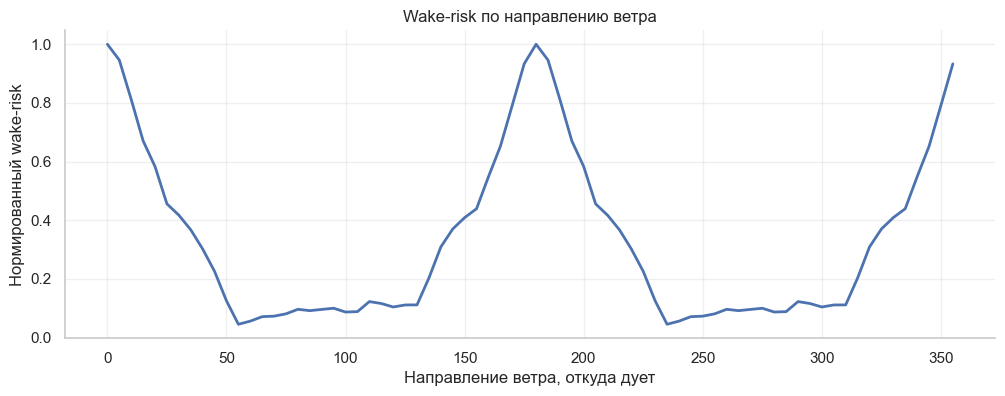

,wind_from_deg,wake_pair_count,wake_risk_score,wake_risk_score_norm
0,0,66,23.082026,1.000000
1,5,66,21.839060,0.946150
2,10,50,18.740340,0.811902
3,15,41,15.480369,0.670668
4,20,41,13.457375,0.583024


In [45]:
def compute_wake_risk_for_direction(
    xy,
    wind_from_deg,
    lateral_threshold_m=WAKE_LATERAL_THRESHOLD_M,
    max_downwind_m=WAKE_MAX_DOWNWIND_M,
    decay_downwind_m=WAKE_DECAY_DOWNWIND_M,
):
    flow_to_deg = (wind_from_deg + 180) % 360
    theta = np.deg2rad(flow_to_deg)

    flow_vec = np.array([np.sin(theta), np.cos(theta)])
    side_vec = np.array([np.cos(theta), -np.sin(theta)])

    pair_count = 0
    weighted_risk = 0.0

    n = len(xy)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue

            delta = xy[j] - xy[i]
            downwind = np.dot(delta, flow_vec)
            lateral = abs(np.dot(delta, side_vec))

            if downwind > 0 and downwind <= max_downwind_m and lateral <= lateral_threshold_m:
                pair_count += 1
                weighted_risk += (
                    np.exp(-downwind / decay_downwind_m)
                    * np.exp(-((lateral / lateral_threshold_m) ** 2))
                )

    return pair_count, weighted_risk


directions = np.arange(0, 360, WAKE_DIRECTION_STEP_DEG)

wake_rows = []

for direction_deg in directions:
    pair_count, risk_score = compute_wake_risk_for_direction(XY, direction_deg)
    wake_rows.append({
        "wind_from_deg": direction_deg,
        "wake_pair_count": pair_count,
        "wake_risk_score": risk_score,
    })

wake_table = pd.DataFrame(wake_rows)

if wake_table["wake_risk_score"].max() > 0:
    wake_table["wake_risk_score_norm"] = (
        wake_table["wake_risk_score"] / wake_table["wake_risk_score"].max()
    )
else:
    wake_table["wake_risk_score_norm"] = 0.0

plt.figure(figsize=(12, 4))
plt.plot(wake_table["wind_from_deg"], wake_table["wake_risk_score_norm"], linewidth=2)
plt.title("Wake-risk по направлению ветра")
plt.xlabel("Направление ветра, откуда дует")
plt.ylabel("Нормированный wake-risk")
plt.grid(alpha=0.3)
plt.show()

display(wake_table.head())

## 9. Modeling frames with spatial and wake features

Собираем train/valid таблицы для моделей: к базовому feature set добавляются `cluster_axis` и `layout_wake_risk_scalar_120m`, а затем при необходимости физическая декомпозиция скрытых потерь.

In [46]:

# Основной wake-признак задан в глобальных настройках
print("BEST_WAKE_FEATURE:", BEST_WAKE_FEATURE)


BEST_WAKE_FEATURE: layout_wake_risk_scalar_120m


In [47]:
def circular_diff_deg(a, b):
    return ((a - b + 180) % 360) - 180


def get_wind_from_deg(frame, direction_col="wind_direction_120m"):
    if direction_col not in frame.columns:
        raise ValueError(f"Нет колонки {direction_col}")
    return (pd.to_numeric(frame[direction_col], errors="coerce") * 1000) % 360


def add_cluster_axis_features(frame):
    out = frame.copy()
    added = []

    wind_from_deg = get_wind_from_deg(out, "wind_direction_120m")
    align_cols = []

    for _, row in cluster_axis_df.iterrows():
        cl = int(row["cluster_id"])
        axis = row["cluster_axis_compass_deg"]

        if np.isnan(axis):
            continue

        diff = circular_diff_deg(wind_from_deg, axis)

        col_align = f"cluster{cl}_axis_alignment"
        col_cross = f"cluster{cl}_axis_crosswind"

        out[col_align] = np.cos(2 * np.deg2rad(diff))
        out[col_cross] = np.sin(2 * np.deg2rad(diff))

        align_cols.append(col_align)
        added += [col_align, col_cross]

    if len(align_cols) > 0:
        out["cluster_axis_alignment_mean"] = out[align_cols].mean(axis=1)
        out["cluster_axis_alignment_max"] = out[align_cols].max(axis=1)
        out["cluster_axis_alignment_min"] = out[align_cols].min(axis=1)

        added += [
            "cluster_axis_alignment_mean",
            "cluster_axis_alignment_max",
            "cluster_axis_alignment_min",
        ]

    return out, added


def add_wake_scalar_feature(frame, feature_name=BEST_WAKE_FEATURE):
    out = frame.copy()
    direction_deg = get_wind_from_deg(out, "wind_direction_120m").to_numpy(dtype=float)

    wt = wake_table[["wind_from_deg", "wake_risk_score_norm"]].dropna().copy()
    wt = wt.sort_values("wind_from_deg")

    xp = wt["wind_from_deg"].to_numpy(dtype=float)
    fp = wt["wake_risk_score_norm"].to_numpy(dtype=float)

    if len(xp) == 0 or not np.isfinite(fp).any():
        out[feature_name] = 0.0
        return out, [feature_name]

    median_risk = float(np.nanmedian(fp))

    xp_wrap = np.r_[xp, xp[0] + 360.0]
    fp_wrap = np.r_[fp, fp[0]]

    direction_for_interp = np.where(np.isfinite(direction_deg), direction_deg, 0.0)

    risk = np.interp(direction_for_interp, xp_wrap, fp_wrap)
    risk[~np.isfinite(direction_deg)] = median_risk
    risk = np.nan_to_num(risk, nan=median_risk, posinf=median_risk, neginf=median_risk)
    risk = np.clip(risk, 0.0, 1.0)

    out[feature_name] = risk

    return out, [feature_name]


def build_model_frames():
    train_out = train_fe.copy()
    valid_out = valid_fe.copy()

    added_cols = []

    train_out, cluster_cols = add_cluster_axis_features(train_out)
    valid_out, _ = add_cluster_axis_features(valid_out)
    added_cols += cluster_cols

    train_out, wake_cols = add_wake_scalar_feature(train_out)
    valid_out, _ = add_wake_scalar_feature(valid_out)
    added_cols += wake_cols

    added_cols = list(dict.fromkeys([
        c for c in added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    model_features = list(dict.fromkeys([
        c for c in model_features_base + added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    return train_out, valid_out, added_cols, model_features



train_model_preview, valid_model_preview, layout_added_features, model_features_preview = build_model_frames()

display(Markdown(
    "### Spatial/wake признаки\n\n"
    "По координатам турбин рассчитаны ориентация кластеров и scalar wake-risk для направления ветра."
))
display(pd.DataFrame([
    {"dataset": "train_model_preview", "rows": train_model_preview.shape[0]},
    {"dataset": "valid_model_preview", "rows": valid_model_preview.shape[0]},
    {"dataset": "wake_signal_available", "rows": bool(BEST_WAKE_FEATURE in model_features_preview)},
]))

### Spatial/wake признаки

По координатам турбин рассчитаны ориентация кластеров и scalar wake-risk для направления ветра.

,dataset,rows
0,train_model_preview,32434
1,valid_model_preview,2126
2,wake_signal_available,True


## 7. Full-physics decomposition и финальные model frames

In [48]:
# ============================================================
# PHYSICAL DECOMPOSITION BLOCK
# P_ideal_clean -> K_hidden -> K_avail + K_perf
# ============================================================

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix, mean_squared_error

# Параметры блока задаются в секции глобальных настроек.
print("FULL_PHYSICS_BLOCK_ENABLED:", FULL_PHYSICS_BLOCK_ENABLED)
print("FULL_OOF_SPLITS:", FULL_OOF_SPLITS)
print("FULL_CHANGEPOINT_WINDOW:", FULL_CHANGEPOINT_WINDOW)
print("FULL_AVAIL_LAMBDA:", FULL_AVAIL_LAMBDA)


FULL_PHYSICS_BLOCK_ENABLED: True
FULL_OOF_SPLITS: 5
FULL_CHANGEPOINT_WINDOW: 72
FULL_AVAIL_LAMBDA: 0.0015


In [49]:
def _full_first_existing(frame, candidates):
    for col in candidates:
        if col in frame.columns:
            return col
    return None


In [50]:
def _full_num(frame, col, default=0.0):
    if col in frame.columns:
        return pd.to_numeric(frame[col], errors="coerce")
    return pd.Series(default, index=frame.index, dtype=float)


In [51]:
def _full_wind_from_deg(frame, direction_col="wind_direction_120m"):
    if direction_col in frame.columns:
        return (pd.to_numeric(frame[direction_col], errors="coerce") * 1000) % 360
    alt_col = _full_first_existing(frame, ["wind_direction_80m", "WD50M", "WD10M", "wind_direction_10m"])
    if alt_col is None:
        return pd.Series(0.0, index=frame.index, dtype=float)
    if alt_col.startswith("wind_direction_"):
        return (pd.to_numeric(frame[alt_col], errors="coerce") * 1000) % 360
    return pd.to_numeric(frame[alt_col], errors="coerce") % 360


In [52]:
def _full_compute_p_ideal_clean(frame):
    out = frame.copy()
    p_col = _full_first_existing(
        out,
        [
            "theoretical_total",
            "P_curve_total",
            "p_curve_total",
            "p_theory_mean_80_120",
            "p_theory_120",
            "p_theory_80",
            "p_empirical_mean_80_120",
        ],
    )
    if p_col is None:
        base = pd.Series(INSTALLED_CAPACITY_MW, index=out.index, dtype=float)
        p_source = "installed_capacity_fallback"
    else:
        base = pd.to_numeric(out[p_col], errors="coerce")
        p_source = p_col

    wake_col = _full_first_existing(out, ["wake_efficiency_factor", "wake_factor", "eta_wake"])
    if wake_col is not None:
        wake_factor = pd.to_numeric(out[wake_col], errors="coerce").clip(0.50, 1.10)
        wake_source = wake_col
    else:
        wake_factor = pd.Series(1.0, index=out.index, dtype=float)
        wake_source = "no_explicit_wake_factor"

    out["full_p_ideal_clean"] = (base * wake_factor).replace([np.inf, -np.inf], np.nan)
    out["full_p_ideal_clean"] = out["full_p_ideal_clean"].clip(0, INSTALLED_CAPACITY_MW * 1.20)
    out.attrs["full_p_ideal_source"] = p_source
    out.attrs["full_wake_source"] = wake_source
    return out


In [53]:
def _full_observed_k_hidden(frame):
    ideal = pd.to_numeric(frame["full_p_ideal_clean"], errors="coerce")
    target = pd.to_numeric(frame["target"], errors="coerce")
    k = pd.Series(np.nan, index=frame.index, dtype=float)
    mask = ideal > FULL_MIN_IDEAL_MW
    k.loc[mask] = 1.0 - target.loc[mask] / (ideal.loc[mask] + EPS)
    return k.clip(FULL_K_HIDDEN_LOW, FULL_K_HIDDEN_HIGH)


In [54]:
def _full_spatial_weight_matrix(frame):
    if "XY" not in globals():
        raise NameError("Не найден XY с координатами турбин. Сначала должна выполниться геометрия ВЭС.")

    xy = np.asarray(XY, dtype=float)
    n_rows = len(frame)
    n_turbines = xy.shape[0]

    wind_from = _full_wind_from_deg(frame).fillna(0).to_numpy(dtype=float)
    weights = np.zeros((n_rows, n_turbines), dtype=float)

    for r, wind_from_deg in enumerate(wind_from):
        flow_to_deg = (wind_from_deg + 180.0) % 360.0
        theta = np.deg2rad(flow_to_deg)
        flow_vec = np.array([np.sin(theta), np.cos(theta)], dtype=float)
        proj = xy @ flow_vec
        proj_range = float(np.nanmax(proj) - np.nanmin(proj))
        if proj_range <= EPS:
            base = np.ones(n_turbines, dtype=float)
        else:
            upwind_score = (np.nanmax(proj) - proj) / (proj_range + EPS)
            base = 1.0 + FULL_UPWIND_WEIGHT_BOOST * upwind_score

        if BEST_WAKE_FEATURE in frame.columns:
            wake_risk = float(pd.to_numeric(frame.iloc[[r]][BEST_WAKE_FEATURE], errors="coerce").iloc[0])
            base = base * (1.0 + 0.20 * np.nan_to_num(wake_risk, nan=0.0))

        base = np.nan_to_num(base, nan=1.0, posinf=1.0, neginf=1.0)
        s = base.sum()
        if s <= EPS:
            weights[r, :] = 1.0 / n_turbines
        else:
            weights[r, :] = base / s

    return weights


In [55]:
def _full_k_avail_from_repair_count(frame, weights):
    repair_count = _full_num(frame, "turbines_in_repair", 0.0).round().clip(0, weights.shape[1]).fillna(0).astype(int).to_numpy()
    out = np.zeros(len(frame), dtype=float)
    for i, m in enumerate(repair_count):
        if m <= 0:
            out[i] = 0.0
        elif m >= weights.shape[1]:
            out[i] = float(weights[i].sum())
        else:
            top_idx = np.argpartition(weights[i], -m)[-m:]
            out[i] = float(weights[i, top_idx].sum())
    return np.clip(out, 0, 1)


In [56]:
def _full_detect_change_points(k_series, window=FULL_CHANGEPOINT_WINDOW, min_distance=FULL_CHANGEPOINT_MIN_DISTANCE):
    k = pd.Series(k_series).astype(float).replace([np.inf, -np.inf], np.nan)
    k_filled = k.interpolate(limit_direction="both").fillna(k.median() if k.notna().any() else 0.0)

    left = k_filled.rolling(window=window, min_periods=max(8, window // 4)).median()
    right = k_filled[::-1].rolling(window=window, min_periods=max(8, window // 4)).median()[::-1]
    score = (right - left).abs().fillna(0.0)

    med = float(score.median())
    mad = float((score - med).abs().median())
    threshold = med + FULL_CHANGEPOINT_THRESHOLD_MAD * 1.4826 * (mad + EPS)

    candidates = np.where(score.to_numpy() > threshold)[0]
    selected = []
    for idx in candidates[np.argsort(score.to_numpy()[candidates])[::-1]]:
        if idx < window or idx > len(k_filled) - window:
            continue
        if all(abs(idx - j) >= min_distance for j in selected):
            selected.append(int(idx))

    selected = sorted(selected)
    boundaries = [0] + selected + [len(k_filled)]

    merged = [boundaries[0]]
    for b in boundaries[1:]:
        if b - merged[-1] < min_distance and b != len(k_filled):
            continue
        merged.append(b)
    if merged[-1] != len(k_filled):
        merged.append(len(k_filled))

    segment_id = np.zeros(len(k_filled), dtype=int)
    for seg, (a, b) in enumerate(zip(merged[:-1], merged[1:])):
        segment_id[a:b] = seg

    score_df = pd.DataFrame({
        "index": np.arange(len(k_filled)),
        "k_hidden_filled": k_filled.to_numpy(),
        "cp_score": score.to_numpy(),
        "segment_id": segment_id,
        "is_boundary": np.isin(np.arange(len(k_filled)), merged[1:-1]).astype(int),
    })
    return segment_id, merged, score_df


In [57]:
def _full_inverse_availability_by_plateau(train_frame, weights, k_hidden):
    segment_id, boundaries, cp_score_df = _full_detect_change_points(k_hidden)

    k_avail_est = np.zeros(len(train_frame), dtype=float)
    off_count_est = np.zeros(len(train_frame), dtype=int)
    plateau_rows = []

    for seg in np.unique(segment_id):
        idx = np.where(segment_id == seg)[0]
        if len(idx) == 0:
            continue

        k_target = float(np.nanmedian(pd.Series(k_hidden).iloc[idx]))
        if not np.isfinite(k_target):
            k_target = 0.0
        k_target = float(np.clip(k_target, 0.0, FULL_K_HIDDEN_HIGH))

        w_bar = np.nanmean(weights[idx], axis=0)
        w_bar = np.nan_to_num(w_bar, nan=1.0 / weights.shape[1])
        order = np.argsort(w_bar)[::-1]

        best_obj = np.inf
        best_m = 0
        best_loss = 0.0
        max_m = min(FULL_MAX_OFF_GRID, weights.shape[1])

        cumulative_loss = np.r_[0.0, np.cumsum(w_bar[order[:max_m]])]
        for m in range(max_m + 1):
            loss = float(cumulative_loss[m])
            obj = (k_target - loss) ** 2 + FULL_AVAIL_LAMBDA * m
            if obj < best_obj:
                best_obj = obj
                best_m = m
                best_loss = loss

        selected_turbines = order[:best_m]
        if best_m > 0:
            k_avail_est[idx] = weights[np.ix_(idx, selected_turbines)].sum(axis=1)
        off_count_est[idx] = best_m

        actual_count_median = float(_full_num(train_frame.iloc[idx], "turbines_in_repair", 0.0).median())
        plateau_rows.append({
            "segment_id": int(seg),
            "start_pos": int(idx.min()),
            "end_pos": int(idx.max()),
            "count": int(len(idx)),
            "k_hidden_median": k_target,
            "estimated_off_count": int(best_m),
            "estimated_loss_mean_weight": best_loss,
            "objective": float(best_obj),
            "actual_repair_count_median": actual_count_median,
            "selected_turbines_1based": ";".join(str(int(t + 1)) for t in selected_turbines),
        })

    plateau_table = pd.DataFrame(plateau_rows)
    return np.clip(k_avail_est, 0, 1), off_count_est, segment_id, plateau_table, cp_score_df


In [58]:
def _full_add_phi_features(frame):
    out = frame.copy()
    phi_cols = []

    temp_col = _full_first_existing(out, ["temperature_80m", "T2M", "temperature_120m"])
    dew_col = _full_first_existing(out, ["T2MDEW"])
    q_col = _full_first_existing(out, ["QV2M"])
    wet_col = _full_first_existing(out, ["T2MWET"])

    if temp_col is not None:
        temp = _full_num(out, temp_col)
        snow = _full_num(out, "snowfall", 0.0)
        rain = _full_num(out, "rain", 0.0) + _full_num(out, "showers", 0.0)
        cloud = _full_num(out, "cloud_cover_low", 0.0)

        humidity = pd.Series(0.0, index=out.index, dtype=float)
        if q_col is not None:
            q = _full_num(out, q_col)
            q95 = np.nanpercentile(q, 95) if np.isfinite(q).any() else 1.0
            humidity = np.clip(q / (q95 + EPS), 0, 1.5)
        elif dew_col is not None:
            dew = _full_num(out, dew_col)
            humidity = np.clip(1 - ((temp - dew).abs() / 10.0), 0, 1.2)
        elif wet_col is not None:
            wet = _full_num(out, wet_col)
            humidity = np.clip(1 - ((temp - wet).abs() / 8.0), 0, 1.2)
        else:
            humidity = np.clip(cloud, 0, 1.2)

        out["phi_ice_risk"] = (((temp <= 2.0).astype(float)) * (0.55 * humidity + 0.30 * (snow > 0).astype(float) + 0.15 * (rain > 0).astype(float))).clip(0, 2)
        out["phi_cold"] = (temp <= 2.0).astype(int)
        out["phi_temp"] = temp
        phi_cols += ["phi_ice_risk", "phi_cold", "phi_temp"]

    if {"wind_gusts_10m", "wind_speed_10m"}.issubset(out.columns):
        out["phi_turbulence"] = ((_full_num(out, "wind_gusts_10m") - _full_num(out, "wind_speed_10m")) / (_full_num(out, "wind_speed_10m") + EPS)).clip(0, 5)
        phi_cols.append("phi_turbulence")
    elif {"WSC", "WS10M"}.issubset(out.columns):
        out["phi_turbulence"] = ((_full_num(out, "WSC") - _full_num(out, "WS10M")) / (_full_num(out, "WS10M") + EPS)).clip(0, 5)
        phi_cols.append("phi_turbulence")

    direction = _full_wind_from_deg(out)
    sorted_pos = np.argsort(pd.to_datetime(out["datetime"], errors="coerce").to_numpy()) if "datetime" in out.columns else np.arange(len(out))
    yaw_abs = pd.Series(0.0, index=out.index, dtype=float)
    if len(out) > 1:
        dir_sorted = direction.iloc[sorted_pos].to_numpy(dtype=float)
        diff_sorted = np.r_[0.0, np.abs(((np.diff(dir_sorted) + 180) % 360) - 180)]
        yaw_abs.iloc[sorted_pos] = diff_sorted
    out["phi_yaw_change_abs_1h"] = yaw_abs.clip(0, 180)
    phi_cols.append("phi_yaw_change_abs_1h")

    for c in [
        "wind_speed_80m", "wind_speed_120m", "wind_speed_180m", "wind_gusts_10m",
        "WS10M", "WS50M", "WSC", "pressure_msl", "PS",
        "p_theory_mean_80_120", "p_empirical_mean_80_120", BEST_WAKE_FEATURE,
        "cluster_axis_alignment_mean", "cluster_axis_alignment_max", "cluster_axis_alignment_min",
    ]:
        if c in out.columns:
            phi_cols.append(c)

    if {"wind_speed_120m", BEST_WAKE_FEATURE}.issubset(out.columns):
        out["phi_wake_x_ws120"] = out[BEST_WAKE_FEATURE] * out["wind_speed_120m"]
        phi_cols.append("phi_wake_x_ws120")

    if {"phi_ice_risk", "wind_speed_120m"}.issubset(out.columns):
        out["phi_ice_x_ws120"] = out["phi_ice_risk"] * out["wind_speed_120m"]
        phi_cols.append("phi_ice_x_ws120")

    phi_cols = list(dict.fromkeys([c for c in phi_cols if c in out.columns]))
    for c in phi_cols:
        out[c] = pd.to_numeric(out[c], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return out, phi_cols


In [59]:
def _full_time_oof_regression(train_frame, valid_frame, feature_cols, target, label):
    X = train_frame[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
    X_valid = valid_frame[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
    y = pd.Series(target, index=train_frame.index, dtype=float).replace([np.inf, -np.inf], np.nan)

    good = y.notna()
    fallback = float(y[good].median()) if good.any() else 0.0
    oof = np.full(len(train_frame), fallback, dtype=float)

    if good.sum() >= 200 and len(feature_cols) > 0:
        n_splits = min(FULL_OOF_SPLITS, max(2, good.sum() // 300))
        splitter = TimeSeriesSplit(n_splits=n_splits, gap=24)
        positions = np.arange(len(train_frame))

        for fold, (tr_pos, te_pos) in enumerate(splitter.split(positions), start=1):
            tr_good = good.iloc[tr_pos].to_numpy()
            if tr_good.sum() < 100:
                continue
            tr_idx = tr_pos[tr_good]
            model = HistGradientBoostingRegressor(
                loss="absolute_error",
                max_iter=260,
                learning_rate=0.045,
                max_leaf_nodes=31,
                l2_regularization=0.05,
                random_state=FULL_RANDOM_STATE + fold,
            )
            model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            oof[te_pos] = model.predict(X.iloc[te_pos])

        final_model = HistGradientBoostingRegressor(
            loss="absolute_error",
            max_iter=360,
            learning_rate=0.04,
            max_leaf_nodes=31,
            l2_regularization=0.05,
            random_state=FULL_RANDOM_STATE + 777,
        )
        final_model.fit(X.loc[good], y.loc[good])
        valid_pred = final_model.predict(X_valid)
    else:
        final_model = None
        valid_pred = np.full(len(valid_frame), fallback, dtype=float)

    return oof, valid_pred, final_model


In [60]:
def _full_rolling_aging_component(train_frame, k_perf_raw):
    tmp = pd.DataFrame({
        "datetime": pd.to_datetime(train_frame["datetime"], errors="coerce"),
        "k_perf_raw": pd.Series(k_perf_raw, index=train_frame.index, dtype=float).clip(-0.50, 0.90),
    }).sort_values("datetime")

    if tmp["k_perf_raw"].notna().sum() == 0:
        return pd.Series(0.0, index=train_frame.index, dtype=float)

    rolled = (
        tmp.set_index("datetime")["k_perf_raw"]
        .rolling("30D", min_periods=48)
        .median()
    )
    rolled = rolled.bfill().ffill().fillna(float(tmp["k_perf_raw"].median()))
    result = pd.Series(index=tmp.index, data=rolled.to_numpy(), dtype=float).reindex(train_frame.index)
    return result.astype(float).clip(-0.30, 0.80)


In [61]:
def add_full_physical_decomposition_features(train_frame, valid_frame):
    train_out = _full_compute_p_ideal_clean(train_frame)
    valid_out = _full_compute_p_ideal_clean(valid_frame)

    train_out, phi_cols_train = _full_add_phi_features(train_out)
    valid_out, phi_cols_valid = _full_add_phi_features(valid_out)
    phi_cols = [c for c in phi_cols_train if c in phi_cols_valid]

    W_train = _full_spatial_weight_matrix(train_out)
    W_valid = _full_spatial_weight_matrix(valid_out)

    train_out["full_k_hidden_observed_train_only"] = _full_observed_k_hidden(train_out)
    k_hidden = train_out["full_k_hidden_observed_train_only"]

    k_avail_est, off_count_est, segment_id, plateau_table, cp_score_df = _full_inverse_availability_by_plateau(train_out, W_train, k_hidden)
    train_out["full_k_avail_est_by_hidden_train_only"] = k_avail_est
    train_out["full_est_turbines_off_by_hidden_train_only"] = off_count_est
    train_out["full_hidden_plateau_id_train_only"] = segment_id

    train_out["full_k_avail_knowncount"] = _full_k_avail_from_repair_count(train_out, W_train)
    valid_out["full_k_avail_knowncount"] = _full_k_avail_from_repair_count(valid_out, W_valid)

    k_perf_raw = (train_out["full_k_hidden_observed_train_only"] - train_out["full_k_avail_est_by_hidden_train_only"]).clip(-0.50, 0.90)
    train_out["full_k_perf_raw_train_only"] = k_perf_raw
    train_out["full_k_aging_target_train_only"] = _full_rolling_aging_component(train_out, k_perf_raw)
    train_out["full_k_meteo_target_train_only"] = (train_out["full_k_perf_raw_train_only"] - train_out["full_k_aging_target_train_only"]).clip(-0.50, 0.70)

    if len(phi_cols) == 0:
        train_out["full_k_meteo_pred"] = 0.0
        valid_out["full_k_meteo_pred"] = 0.0
        train_out["full_k_aging_pred"] = float(train_out["full_k_aging_target_train_only"].median()) if train_out["full_k_aging_target_train_only"].notna().any() else 0.0
        valid_out["full_k_aging_pred"] = float(train_out["full_k_aging_pred"].median())
        meteo_model = None
        aging_model = None
    else:
        meteo_oof, meteo_valid, meteo_model = _full_time_oof_regression(
            train_out,
            valid_out,
            phi_cols,
            train_out["full_k_meteo_target_train_only"],
            label="k_meteo",
        )
        aging_oof, aging_valid, aging_model = _full_time_oof_regression(
            train_out,
            valid_out,
            phi_cols + [c for c in ["month", "dayofyear", "hour_of_day"] if c in train_out.columns and c in valid_out.columns],
            train_out["full_k_aging_target_train_only"],
            label="k_aging",
        )
        train_out["full_k_meteo_pred"] = np.clip(meteo_oof, -0.50, 0.70)
        valid_out["full_k_meteo_pred"] = np.clip(meteo_valid, -0.50, 0.70)
        train_out["full_k_aging_pred"] = np.clip(aging_oof, -0.30, 0.80)
        valid_out["full_k_aging_pred"] = np.clip(aging_valid, -0.30, 0.80)

    for frame in [train_out, valid_out]:
        frame["full_k_perf_pred"] = (frame["full_k_aging_pred"] + frame["full_k_meteo_pred"]).clip(-0.50, 0.90)
        frame["full_k_hidden_pred"] = (frame["full_k_avail_knowncount"] + frame["full_k_perf_pred"]).clip(FULL_K_HIDDEN_LOW, FULL_K_HIDDEN_HIGH)
        frame["full_hidden_loss_mw_pred"] = (frame["full_p_ideal_clean"] * frame["full_k_hidden_pred"]).clip(-20, INSTALLED_CAPACITY_MW)
        frame["full_p_reconstructed"] = (frame["full_p_ideal_clean"] * (1 - frame["full_k_hidden_pred"])).clip(0, INSTALLED_CAPACITY_MW)
        if "p_empirical_mean_80_120" in frame.columns:
            frame["full_recon_minus_empirical_curve"] = frame["full_p_reconstructed"] - frame["p_empirical_mean_80_120"]
        if BEST_WAKE_FEATURE in frame.columns:
            frame["full_k_hidden_x_wake"] = frame["full_k_hidden_pred"] * frame[BEST_WAKE_FEATURE]
        if "phi_ice_risk" in frame.columns:
            frame["full_k_meteo_x_ice"] = frame["full_k_meteo_pred"] * frame["phi_ice_risk"]

    actual_event = (_full_num(train_out, "turbines_in_repair", 0.0).round() > 0).astype(int)
    pred_event = (train_out["full_est_turbines_off_by_hidden_train_only"] > 0).astype(int)
    detector_report = pd.DataFrame([
        {
            "metric": "availability_event_f1",
            "value": f1_score(actual_event, pred_event, zero_division=0),
        },
        {
            "metric": "availability_event_accuracy",
            "value": accuracy_score(actual_event, pred_event),
        },
        {
            "metric": "estimated_off_mae_vs_repair_count",
            "value": np.mean(np.abs(train_out["full_est_turbines_off_by_hidden_train_only"] - _full_num(train_out, "turbines_in_repair", 0.0).round())),
        },
    ])

    cm = confusion_matrix(actual_event, pred_event, labels=[0, 1])
    detector_cm = pd.DataFrame(cm, index=["actual_no_repair", "actual_repair"], columns=["pred_no_repair", "pred_repair"])

    oot_mask = np.arange(len(train_out)) >= int(len(train_out) * 0.8)
    oot_df = train_out.loc[oot_mask].copy()
    oot_df["full_recon_abs_error"] = (oot_df["full_p_reconstructed"] - oot_df["target"]).abs()
    oot_df["ideal_abs_error"] = (oot_df["full_p_ideal_clean"].clip(0, INSTALLED_CAPACITY_MW) - oot_df["target"]).abs()
    if "p_empirical_mean_80_120" in oot_df.columns:
        oot_df["empirical_curve_abs_error"] = (oot_df["p_empirical_mean_80_120"].clip(0, INSTALLED_CAPACITY_MW) - oot_df["target"]).abs()
    else:
        oot_df["empirical_curve_abs_error"] = np.nan

    oot_report = pd.DataFrame([
        {
            "metric": "oot_mae_full_physical_reconstruction",
            "value": float(oot_df["full_recon_abs_error"].mean()),
        },
        {
            "metric": "oot_mae_p_ideal_clean",
            "value": float(oot_df["ideal_abs_error"].mean()),
        },
        {
            "metric": "oot_mae_empirical_curve",
            "value": float(oot_df["empirical_curve_abs_error"].mean()),
        },
        {
            "metric": "oot_delta_full_vs_ideal",
            "value": float(oot_df["full_recon_abs_error"].mean() - oot_df["ideal_abs_error"].mean()),
        },
    ])

    added = [
        "full_p_ideal_clean",
        "full_k_avail_knowncount",
        "full_k_aging_pred",
        "full_k_meteo_pred",
        "full_k_perf_pred",
        "full_k_hidden_pred",
        "full_hidden_loss_mw_pred",
        "full_p_reconstructed",
        "full_recon_minus_empirical_curve",
        "full_k_hidden_x_wake",
        "full_k_meteo_x_ice",
    ] + phi_cols
    added = list(dict.fromkeys([c for c in added if c in train_out.columns and c in valid_out.columns]))

    diagnostics = {
        "plateau_table": plateau_table,
        "cp_score_df": cp_score_df,
        "detector_report": detector_report,
        "detector_confusion_matrix": detector_cm,
        "oot_report": oot_report,
        "oot_rows": oot_df[[c for c in ["datetime", "target", "full_p_ideal_clean", "full_p_reconstructed", "full_recon_abs_error", "ideal_abs_error", "empirical_curve_abs_error"] if c in oot_df.columns]].copy(),
        "phi_cols": pd.DataFrame({"phi_feature": phi_cols}),
    }

    return train_out, valid_out, added, diagnostics


_base_build_model_frames = build_model_frames


### Full-physics диагностика

Таблицы ниже проверяют детектор доступности и OOT-реконструкцию скрытых потерь.

,metric,value
0,diagnostics_saved,True


,metric,value
0,availability_event_f1,0.053298
1,availability_event_accuracy,0.027379
2,estimated_off_mae_vs_repair_count,4.033545


,metric,value
0,oot_mae_full_physical_reconstruction,12.857712
1,oot_mae_p_ideal_clean,13.407371
2,oot_mae_empirical_curve,9.119531
3,oot_delta_full_vs_ideal,-0.549660


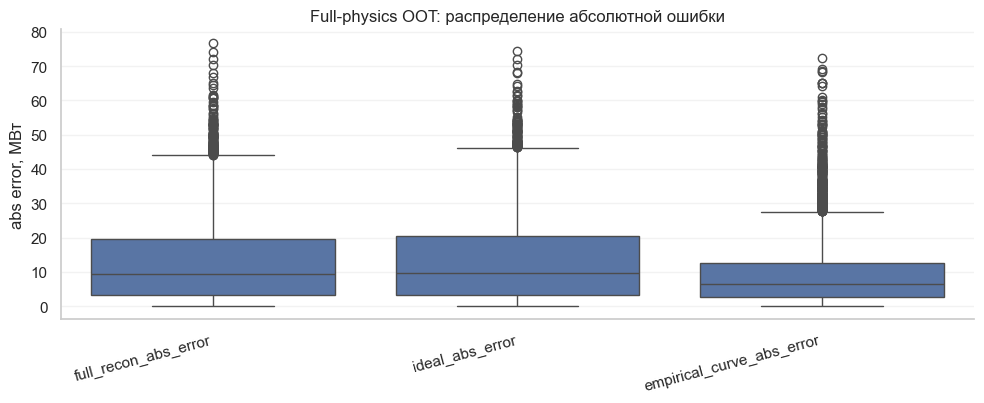

Saved plot: outputs\figures\06_full_physics_oot_error_boxplot.png


### Сборка модельных таблиц

Train и valid подготовлены для direct ensemble и two-stage блоков.

,dataset,rows
0,train_model_preview,32434
1,valid_model_preview,2126


In [62]:
def build_model_frames():
    train_out = train_fe.copy()
    valid_out = valid_fe.copy()

    added_cols = []

    train_out, cluster_cols = add_cluster_axis_features(train_out)
    valid_out, _ = add_cluster_axis_features(valid_out)
    added_cols += cluster_cols

    train_out, wake_cols = add_wake_scalar_feature(train_out)
    valid_out, _ = add_wake_scalar_feature(valid_out)
    added_cols += wake_cols

    if FULL_PHYSICS_BLOCK_ENABLED:
        train_out, valid_out, full_cols, full_diag = add_full_physical_decomposition_features(train_out, valid_out)
        added_cols += full_cols

        if SAVE_DIAGNOSTIC_ARTIFACTS:
            LOG_DIR.mkdir(parents=True, exist_ok=True)
            full_diag["plateau_table"].to_csv(LOG_DIR / "full_hidden_plateaus.csv", index=False)
            full_diag["cp_score_df"].to_csv(LOG_DIR / "full_changepoint_scores.csv", index=False)
            full_diag["detector_report"].to_csv(LOG_DIR / "full_availability_detector_report.csv", index=False)
            full_diag["detector_confusion_matrix"].to_csv(LOG_DIR / "full_availability_confusion_matrix.csv")
            full_diag["oot_report"].to_csv(LOG_DIR / "full_physics_oot_report.csv", index=False)
            full_diag["oot_rows"].to_csv(LOG_DIR / "full_physics_oot_rows.csv", index=False)
            full_diag["phi_cols"].to_csv(LOG_DIR / "full_phi_features.csv", index=False)

        display(Markdown(
            "### Full-physics диагностика\n\n"
            "Таблицы ниже проверяют детектор доступности и OOT-реконструкцию скрытых потерь."
        ))
        display(pd.DataFrame([
            {"metric": "diagnostics_saved", "value": SAVE_DIAGNOSTIC_ARTIFACTS},
        ]))
        display(full_diag["detector_report"])
        display(full_diag["oot_report"])

        if PLOT_RESEARCH_OUTPUTS and len(full_diag["oot_rows"]) > 0:
            oot_plot = full_diag["oot_rows"].copy()
            error_cols = [
                col for col in ["full_recon_abs_error", "ideal_abs_error", "empirical_curve_abs_error"]
                if col in oot_plot.columns
            ]
            if len(error_cols) > 0:
                error_long = oot_plot[error_cols].melt(var_name="series", value_name="abs_error_mw").dropna()
                plt.figure(figsize=(10, 4.2))
                sns.boxplot(data=error_long, x="series", y="abs_error_mw")
                plt.title("Full-physics OOT: распределение абсолютной ошибки")
                plt.xlabel("")
                plt.ylabel("abs error, МВт")
                plt.xticks(rotation=15, ha="right")
                plt.tight_layout()
                plot_path = RESEARCH_PLOT_DIR / "06_full_physics_oot_error_boxplot.png"
                plt.savefig(plot_path, dpi=180, bbox_inches="tight")
                plt.show()
                print("Saved plot:", plot_path)

    added_cols = list(dict.fromkeys([
        c for c in added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    model_features = list(dict.fromkeys([
        c for c in model_features_base + added_cols
        if c in train_out.columns and c in valid_out.columns
    ]))

    return train_out, valid_out, added_cols, model_features


full_train_preview, full_valid_preview, full_added_cols, full_feature_cols_preview = build_model_frames()
display(Markdown(
    "### Сборка модельных таблиц\n\n"
    "Train и valid подготовлены для direct ensemble и two-stage блоков."
))
display(pd.DataFrame([
    {"dataset": "train_model_preview", "rows": full_train_preview.shape[0]},
    {"dataset": "valid_model_preview", "rows": full_valid_preview.shape[0]},
]))

In [63]:
# ============================================================
# CHECK: full-physics columns
# ============================================================

full_feature_check = [
    c for c in full_feature_cols_preview
    if c.startswith("full_") or c.startswith("phi_")
]

required_full_cols = [
    "full_p_ideal_clean",
    "full_k_avail_knowncount",
    "full_k_aging_pred",
    "full_k_meteo_pred",
    "full_k_perf_pred",
    "full_k_hidden_pred",
    "full_hidden_loss_mw_pred",
    "full_p_reconstructed",
    "full_recon_minus_empirical_curve",
]

missing_full_cols = [
    c for c in required_full_cols
    if c not in full_train_preview.columns or c not in full_valid_preview.columns
]

display(Markdown("### Контроль full-physics колонок"))
if len(missing_full_cols) > 0:
    display(pd.DataFrame({"missing_required_full_col": missing_full_cols}))
else:
    display(pd.DataFrame([{"status": "required full-physics columns are present"}]))

if len(full_feature_check) == 0:
    raise RuntimeError("FULL-ФИЗИКА НЕ ПОПАЛА В model_features. Такой запуск вернёт clean/baseline результат.")

### Контроль full-physics колонок

,status
0,required full-physics columns are present


## 10.1 Modeling dataset preparation

Финальные модельные таблицы формируются через явный `copy()`: исходные `train_fe` и `valid_fe` не мутируются скрыто. После сборки проверяем состав feature list и сохраняем его при включённой диагностике.

In [64]:
modeling_dataset_report = pd.DataFrame([{
    "train_rows": full_train_preview.shape[0],
    "valid_rows": full_valid_preview.shape[0],
    "n_added_features": len(full_added_cols),
    "n_model_features": len(full_feature_cols_preview),
    "has_target": "target" in full_train_preview.columns,
    "has_row_id_valid": "row_id" in full_valid_preview.columns,
}])
display(modeling_dataset_report)

if SAVE_DIAGNOSTIC_ARTIFACTS:
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    pd.DataFrame({"feature": full_feature_cols_preview}).to_csv(LOG_DIR / "final_model_features.csv", index=False)


,train_rows,valid_rows,n_added_features,n_model_features,has_target,has_row_id_valid
0,32434,2126,41,181,True,True


## 8. High-wind признаки и сохранение feature contract

In [65]:
# ============================================================
# EMPIRICAL HIGH-WIND CLIP
# ============================================================

# Параметры high-wind clip заданы в секции глобальных настроек.
print("HIGH_WIND_CLIP_ENABLED:", HIGH_WIND_CLIP_ENABLED)
print("HIGH_WIND_SPEED_COL:", HIGH_WIND_SPEED_COL)
print("HIGH_WIND_START_WS:", HIGH_WIND_START_WS)
print("HIGH_WIND_CAP_QUANTILE:", HIGH_WIND_CAP_QUANTILE)
print("HIGH_WIND_CLIP_STRENGTH:", HIGH_WIND_CLIP_STRENGTH)


HIGH_WIND_CLIP_ENABLED: True
HIGH_WIND_SPEED_COL: wind_speed_120m
HIGH_WIND_START_WS: 11.5
HIGH_WIND_CAP_QUANTILE: 0.7
HIGH_WIND_CLIP_STRENGTH: 0.85


In [66]:
def sigmoid_np(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -50, 50)))


In [67]:
def fit_high_wind_cap_curve(
    reference,
    speed_col=HIGH_WIND_SPEED_COL,
    target_col="target",
    start_ws=HIGH_WIND_START_WS,
    bin_width=HIGH_WIND_CAP_BIN_WIDTH,
    min_count=HIGH_WIND_CAP_MIN_COUNT,
    quantile=HIGH_WIND_CAP_QUANTILE,
    rolling_window=HIGH_WIND_CAP_ROLLING_WINDOW,
    margin_mw=HIGH_WIND_CAP_MARGIN_MW,
    hard_max_cap=HIGH_WIND_HARD_MAX_CAP,
):
    """
    Строит empirical high-wind cap по фактической выработке train.

    Особенность этой эмпирической cap-кривой:
    - берём только строки с wind >= start_ws;
    - cap НЕ обязан быть монотонным;
    - cap ограничивается hard_max_cap, чтобы не улетать к 80+ МВт;
    - итоговая линия получается ближе к реальному потолку факта при сильном ветре.
    """
    if speed_col not in reference.columns:
        raise ValueError(f"Нет speed_col: {speed_col}")

    if target_col not in reference.columns:
        raise ValueError(f"Нет target_col: {target_col}")

    ref = reference[[speed_col, target_col]].copy()
    ref[speed_col] = pd.to_numeric(ref[speed_col], errors="coerce")
    ref[target_col] = pd.to_numeric(ref[target_col], errors="coerce")
    ref = ref.replace([np.inf, -np.inf], np.nan).dropna()

    if len(ref) == 0:
        raise ValueError("Пустой reference для high-wind cap curve.")

    high_ref = ref[ref[speed_col] >= start_ws].copy()

    # Защита на случай, если в конкретном split мало high-wind точек.
    if len(high_ref) < max(20, min_count * 2):
        high_ref = ref.copy()

    high_ref["ws_bin"] = (high_ref[speed_col] / bin_width).round() * bin_width

    cap_curve = (
        high_ref
        .groupby("ws_bin", observed=True)
        .agg(
            count=(target_col, "size"),
            speed_mean=(speed_col, "mean"),
            target_mean=(target_col, "mean"),
            target_median=(target_col, "median"),
            target_q=(target_col, lambda x: np.quantile(x, quantile)),
            target_max=(target_col, "max"),
        )
        .reset_index()
        .sort_values("speed_mean")
        .reset_index(drop=True)
    )

    cap_curve = cap_curve[cap_curve["count"] >= min_count].copy()
    cap_curve = cap_curve.sort_values("speed_mean").reset_index(drop=True)

    if len(cap_curve) < 2:
        fallback_cap = float(np.nanquantile(high_ref[target_col], quantile) + margin_mw)
        fallback_cap = float(np.clip(fallback_cap, 0, min(hard_max_cap, INSTALLED_CAPACITY_MW)))
        max_speed = max(float(high_ref[speed_col].max()), start_ws + 1.0)
        cap_curve = pd.DataFrame({
            "ws_bin": [start_ws, max_speed],
            "count": [len(high_ref), len(high_ref)],
            "speed_mean": [start_ws, max_speed],
            "target_mean": [fallback_cap, fallback_cap],
            "target_median": [fallback_cap, fallback_cap],
            "target_q": [fallback_cap, fallback_cap],
            "target_max": [fallback_cap, fallback_cap],
        })

    cap_curve["cap_raw"] = cap_curve["target_q"] + margin_mw

    # Сглаживаем, чтобы cap не прыгал от бина к бину.
    if rolling_window and rolling_window > 1 and len(cap_curve) >= rolling_window:
        cap_curve["cap_smooth"] = (
            cap_curve["cap_raw"]
            .rolling(rolling_window, center=True, min_periods=1)
            .median()
        )
    else:
        cap_curve["cap_smooth"] = cap_curve["cap_raw"]

    # Главная защита: high-wind cap не должен быть выше реалистичного потолка.
    cap_curve["cap_final"] = np.minimum(cap_curve["cap_smooth"], hard_max_cap)
    cap_curve["cap_final"] = cap_curve["cap_final"].clip(0, INSTALLED_CAPACITY_MW)

    # Служебные параметры, чтобы потом в csv было видно, как строилась таблица.
    cap_curve["start_ws"] = start_ws
    cap_curve["quantile"] = quantile
    cap_curve["margin_mw"] = margin_mw
    cap_curve["hard_max_cap"] = hard_max_cap
    cap_curve["bin_width"] = bin_width

    return cap_curve


In [68]:
def apply_high_wind_smart_clip(
    frame,
    pred_values,
    cap_curve,
    speed_col=HIGH_WIND_SPEED_COL,
    start_ws=HIGH_WIND_START_WS,
    transition=HIGH_WIND_TRANSITION,
    strength=HIGH_WIND_CLIP_STRENGTH,
    min_pred=HIGH_WIND_MIN_PRED,
    max_pred=HIGH_WIND_MAX_PRED,
):
    """
    Мягкий high-wind clip:
    corrected = pred - strength * gate(high wind) * max(pred - empirical_cap, 0)

    empirical_cap берётся из train-факта по high-wind бинам.
    """
    if speed_col not in frame.columns:
        raise ValueError(f"Нет speed_col: {speed_col}")

    if "cap_final" not in cap_curve.columns:
        raise ValueError("В cap_curve нет колонки cap_final")

    pred = np.asarray(pred_values, dtype=float)
    ws = pd.to_numeric(frame[speed_col], errors="coerce").to_numpy(dtype=float)

    curve_x = cap_curve["speed_mean"].to_numpy(dtype=float)
    curve_y = cap_curve["cap_final"].to_numpy(dtype=float)

    order = np.argsort(curve_x)
    curve_x = curve_x[order]
    curve_y = curve_y[order]

    ws_safe = np.nan_to_num(ws, nan=np.nanmedian(curve_x))

    cap = np.interp(
        ws_safe,
        curve_x,
        curve_y,
        left=curve_y[0],
        right=curve_y[-1],
    )

    cap = np.clip(cap, min_pred, max_pred)

    gate = sigmoid_np((ws_safe - start_ws) / transition)
    gate = np.nan_to_num(gate, nan=0.0)

    excess = np.maximum(pred - cap, 0.0)
    corrected = pred - strength * gate * excess
    corrected = np.clip(corrected, min_pred, max_pred)

    diagnostics = pd.DataFrame({
        "high_wind_speed": ws,
        "pred_raw": pred,
        "high_wind_cap_final": cap,
        "high_wind_gate": gate,
        "high_wind_excess": excess,
        "pred_clipped": corrected,
        "clip_delta": corrected - pred,
    })

    return corrected, diagnostics


In [69]:
def tune_high_wind_clip_params(
    train_part,
    eval_part,
    eval_pred,
    target_col="target",
    speed_col=HIGH_WIND_SPEED_COL,
):
    """
    Grid-search только для диагностики.
    Он НЕ использует valid target и НЕ обязан автоматически применяться в финальном submission.
    """
    y_true = eval_part[target_col].clip(0, INSTALLED_CAPACITY_MW).to_numpy()
    baseline_mae = mean_absolute_error(y_true, np.clip(eval_pred, 0, INSTALLED_CAPACITY_MW))

    rows = []

    for start_ws in [11.0, 11.5, 12.0]:
        for quantile in [0.60, 0.65, 0.70, 0.75]:
            for margin_mw in [0.0, 1.0, 1.5, 2.0, 3.0]:
                for hard_max_cap in [74.0, 75.0, 76.0, 77.0, 78.0]:
                    for strength in [0.65, 0.80, 0.95, 1.00]:
                        cap_curve = fit_high_wind_cap_curve(
                            train_part,
                            speed_col=speed_col,
                            target_col=target_col,
                            start_ws=start_ws,
                            quantile=quantile,
                            margin_mw=margin_mw,
                            hard_max_cap=hard_max_cap,
                        )

                        clipped_pred, clip_diag = apply_high_wind_smart_clip(
                            eval_part,
                            eval_pred,
                            cap_curve,
                            speed_col=speed_col,
                            start_ws=start_ws,
                            strength=strength,
                        )

                        mae = mean_absolute_error(y_true, clipped_pred)

                        high_mask = pd.to_numeric(eval_part[speed_col], errors="coerce") >= start_ws
                        high_delta = clip_diag.loc[high_mask.to_numpy(), "clip_delta"]

                        rows.append({
                            "start_ws": start_ws,
                            "quantile": quantile,
                            "margin_mw": margin_mw,
                            "hard_max_cap": hard_max_cap,
                            "strength": strength,
                            "mae": mae,
                            "mae_delta_vs_raw": mae - baseline_mae,
                            "changed_share": (np.abs(clip_diag["clip_delta"]) > 1e-9).mean(),
                            "high_wind_changed_share": (np.abs(high_delta) > 1e-9).mean() if len(high_delta) else 0.0,
                            "mean_delta": clip_diag["clip_delta"].mean(),
                            "min_delta": clip_diag["clip_delta"].min(),
                        })

    return pd.DataFrame(rows).sort_values("mae").reset_index(drop=True)


## 11.1 Post-processing parameters

Параметры high-wind clip задают начало режима сильного ветра, квантиль empirical cap-кривой, запас до потолка и силу применения клипа.

In [70]:
high_wind_config_report = pd.DataFrame([{
    "speed_col": HIGH_WIND_SPEED_COL,
    "start_ws": HIGH_WIND_START_WS,
    "transition": HIGH_WIND_TRANSITION,
    "cap_quantile": HIGH_WIND_CAP_QUANTILE,
    "cap_margin_mw": HIGH_WIND_CAP_MARGIN_MW,
    "hard_max_cap": HIGH_WIND_HARD_MAX_CAP,
    "clip_strength": HIGH_WIND_CLIP_STRENGTH,
}])
display(high_wind_config_report)


,speed_col,start_ws,transition,cap_quantile,cap_margin_mw,hard_max_cap,clip_strength
0,wind_speed_120m,11.5,0.45,0.7,1.5,77.0,0.85


In [71]:
import json
import joblib
import ves_pipeline_core as vpc

# Sequential notebook step; kept inline instead of a one-shot wrapper.
# Sequential notebook step; kept inline instead of a one-shot wrapper.
train_features = full_train_preview.copy()
valid_features = full_valid_preview.copy()
model_features = list(full_feature_cols_preview)

high_wind_feature_curve = fit_high_wind_cap_curve(
    train_features,
    speed_col=HIGH_WIND_SPEED_COL,
    target_col="target",
)
curve_x = high_wind_feature_curve["speed_mean"].to_numpy(dtype=float)
curve_y = high_wind_feature_curve["cap_final"].to_numpy(dtype=float)
order = np.argsort(curve_x)
curve_x = curve_x[order]
curve_y = curve_y[order]
median_curve_x = float(np.nanmedian(curve_x))

for frame in [train_features, valid_features]:
    ws = pd.to_numeric(frame[HIGH_WIND_SPEED_COL], errors="coerce").to_numpy(dtype=float)
    ws_safe = np.nan_to_num(ws, nan=median_curve_x)
    cap = np.interp(ws_safe, curve_x, curve_y, left=curve_y[0], right=curve_y[-1])
    gate = sigmoid_np((ws_safe - HIGH_WIND_START_WS) / HIGH_WIND_TRANSITION)

    frame["high_wind_cap_feature"] = np.clip(cap, 0, INSTALLED_CAPACITY_MW)
    frame["high_wind_gate_feature"] = np.nan_to_num(gate, nan=0.0)
    if "p_empirical_mean_80_120" in frame.columns:
        frame["high_wind_cap_minus_empirical"] = frame["high_wind_cap_feature"] - frame["p_empirical_mean_80_120"]
    if "p_theory_mean_80_120" in frame.columns:
        frame["high_wind_cap_minus_theory"] = frame["high_wind_cap_feature"] - frame["p_theory_mean_80_120"]

high_wind_feature_cols = [
    col for col in [
        "high_wind_cap_feature",
        "high_wind_gate_feature",
        "high_wind_cap_minus_empirical",
        "high_wind_cap_minus_theory",
    ]
    if col in train_features.columns and col in valid_features.columns
]
model_features = list(dict.fromkeys(model_features + high_wind_feature_cols))

# Sequential notebook step; kept inline instead of a one-shot wrapper.
# Sequential notebook step; kept inline instead of a one-shot wrapper.
test_raw = pd.read_csv(vpc.TEST_PATH)
test_pair = vpc._build_feature_pair(train_raw, test_raw, eval_name="test", verbose=False)
test_features = test_pair["eval_features"].copy()

for frame in [train_features, valid_features, test_features]:
    for col in model_features:
        if col not in frame.columns:
            frame[col] = np.nan

vpc.DATASET_DIR.mkdir(parents=True, exist_ok=True)
train_features.to_csv(vpc.TRAIN_FEATURES_PATH, index=False)
valid_features.to_csv(vpc.VALID_FEATURES_PATH, index=False)
test_features.to_csv(vpc.TEST_FEATURES_PATH, index=False)

# Sequential notebook step; kept inline instead of a one-shot wrapper.
datetime_col_test = next((c for c in DATETIME_CANDIDATES if c in test_raw.columns), None)
target_col_test = next((c for c in TARGET_CANDIDATES if c in test_raw.columns), None)
test_actual = pd.DataFrame({"row_id": np.arange(len(test_raw))})
if datetime_col_test is not None:
    test_actual["datetime"] = pd.to_datetime(test_raw[datetime_col_test], errors="coerce")
if target_col_test is not None:
    test_actual["actual_mw"] = pd.to_numeric(test_raw[target_col_test], errors="coerce")
for col in ["wind_speed_120m", "wind_speed_80m", "wind_direction_120m", "\u041a\u043e\u043b-\u0432\u043e_\u0412\u042d\u0423_\u0432_\u0440\u0435\u043c\u043e\u043d\u0442\u0435"]:
    if col in test_raw.columns:
        test_actual[col] = test_raw[col].to_numpy()
test_actual.to_csv(vpc.TEST_ACTUAL_PATH, index=False)

vpc.MODEL_FEATURES_PATH.write_text(
    json.dumps({"model_features": model_features}, ensure_ascii=False, indent=2),
    encoding="utf-8",
)
feature_artifacts = {
    "model_features": model_features,
    "high_wind_cap_curve": high_wind_feature_curve,
    "row_counts": {"train": len(train_features), "valid": len(valid_features), "test": len(test_features)},
}
joblib.dump(feature_artifacts, vpc.FEATURE_ARTIFACTS_PATH)

feature_contract = vpc.validate_feature_contract()
display(Markdown("### Saved feature contract"))
display(feature_contract)
display(pd.DataFrame([
    {"artifact": "train_features", "path": str(vpc.TRAIN_FEATURES_PATH), "rows": len(train_features)},
    {"artifact": "valid_features", "path": str(vpc.VALID_FEATURES_PATH), "rows": len(valid_features)},
    {"artifact": "test_features", "path": str(vpc.TEST_FEATURES_PATH), "rows": len(test_features)},
    {"artifact": "model_features", "path": str(vpc.MODEL_FEATURES_PATH), "rows": len(model_features)},
    {"artifact": "feature_artifacts", "path": str(vpc.FEATURE_ARTIFACTS_PATH), "rows": 1},
]))


### Контрольный снимок конфигурации

Пути, физические блоки, high-wind clip и two-stage параметры текущего запуска.

,group,parameter,value
0,paths,TRAIN_PATH,data\train_merged.csv
1,paths,VALID_PATH,data\valid_merged.csv
2,paths,TURBINE_COORDS_PATH,map\data\wind_farm_coords.csv
3,paths,OUT_DIR,outputs
4,paths,SUB_PATH,outputs\submission_final.csv
5,paths,SAVE_DIAGNOSTIC_ARTIFACTS,False
6,paths,SAVE_DIRECT_DEBUG_SUBMISSIONS,False
7,direct,BLEND_WEIGHTS_SUM,1.000001
8,direct,DIRECT_ENSEMBLE_FAST_MODE,False
9,physics,FULL_PHYSICS_BLOCK_ENABLED,True


N_LAYOUT_CLUSTERS: 4
WAKE_DIRECTION_STEP_DEG: 5
BEST_WAKE_FEATURE: layout_wake_risk_scalar_120m
ГЕОМЕТРИЯ ВЭС
Турбин: 26
Среднее ближайшее расстояние: 343.0 м
Медианное ближайшее расстояние: 353.6 м
Главная ось ВЭС: 9.30° / 189.30°
Доля объяснённой дисперсии PCA: [0.69031765 0.30968235]
2. Генерация базовых признаков...
3. EMA и NWP-соседи...
4. Эмпирическая кривая мощности...
BLEND_WEIGHTS sum: 1.000001
ENSEMBLE_PARAMS_FULL: {'cat_iter': 1200, 'xgb_estimators': 900, 'lgb_estimators': 900, 'hgb_iter': 650}
HGB_QUANTILES: [0.545, 0.57, 0.53]
BEST_WAKE_FEATURE: layout_wake_risk_scalar_120m
FULL_PHYSICS_BLOCK_ENABLED: True
FULL_OOF_SPLITS: 5
FULL_CHANGEPOINT_WINDOW: 72
FULL_AVAIL_LAMBDA: 0.0015
TWO_STAGE_ENABLED: True
TWO_STAGE_FAST_MODE: False
TWO_STAGE_N_SPLITS: 5
FINAL_TWO_STAGE_ALPHA: 0.1
TS_DIR: outputs\ts


### Saved feature contract

,dataset,feature_rows,raw_rows,row_count_ok,missing_model_features
0,train,32434,32434,True,0
1,valid,2126,2126,True,0
2,test,1152,1152,True,0


,artifact,path,rows
0,train_features,outputs\datasets\train_features.csv,32434
1,valid_features,outputs\datasets\valid_features.csv,2126
2,test_features,outputs\datasets\test_features.csv,1152
3,model_features,outputs\datasets\model_features.json,185
4,feature_artifacts,outputs\datasets\feature_artifacts.joblib,1


In [72]:
feature_frames = {
    "train": train_features,
    "valid": valid_features,
    "test": test_features,
}

display(Markdown("### Model-feature missing-value report"))
display(pd.DataFrame([
    {
        "dataset": name,
        "rows": len(frame),
        "columns": frame.shape[1],
        "missing_model_features": sum(col not in frame.columns for col in model_features),
        "mean_na_share_in_model_features": frame[model_features].isna().mean().mean(),
    }
    for name, frame in feature_frames.items()
]))


### Model-feature missing-value report

,dataset,rows,columns,missing_model_features,mean_na_share_in_model_features
0,train,32434,213,0,0.017473
1,valid,2126,206,0,0.003051
2,test,1152,206,0,0.010135
